In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
import re
import time

import gensim
from gensim.models import Word2Vec

from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from nltk.tokenize import WordPunctTokenizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# PyTorch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [ ]:
train_df = pd.read_csv(r"D:\fabia\Training_data_11.csv")
test_df  = pd.read_csv(r"D:\fabia\Test_data.csv")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()

Train shape: (95440, 2)
Test shape:  (12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Presi...,Business
1,<html> <body> News Headlines:\n <br> <b> Will ...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Updat...,Business
3,<html> <body> News Headlines:\n <br> <b> Workp...,Business
4,<html> <body> News Headlines:\n <br> <b> Fish ...,Sports


In [ ]:
# Basic descriptive statistics of the training set

train_df.describe()

,News Headline,News Topic
count,95440,95440
unique,83161,4
top,<html> <body> News Headlines:\n <br> <b> Georg...,Business
freq,7,30563


In [ ]:
# null presence
print(train_df.isnull().sum())
print(test_df.isnull().sum())

News Headline    0
News Topic       0
dtype: int64
News Headline    0
News Topic       0
dtype: int64


In [ ]:
# duplicate
duplicates = train_df['News Headline'].duplicated().sum()
print("Number of duplicate headlines:", duplicates)


# removing them could disturb class balance

Number of duplicate headlines: 12279


In [ ]:
# Verify data types in the News Headline column
train_df['News Headline'].apply(type).value_counts()

News Headline
<class 'str'>    95440
Name: count, dtype: int64

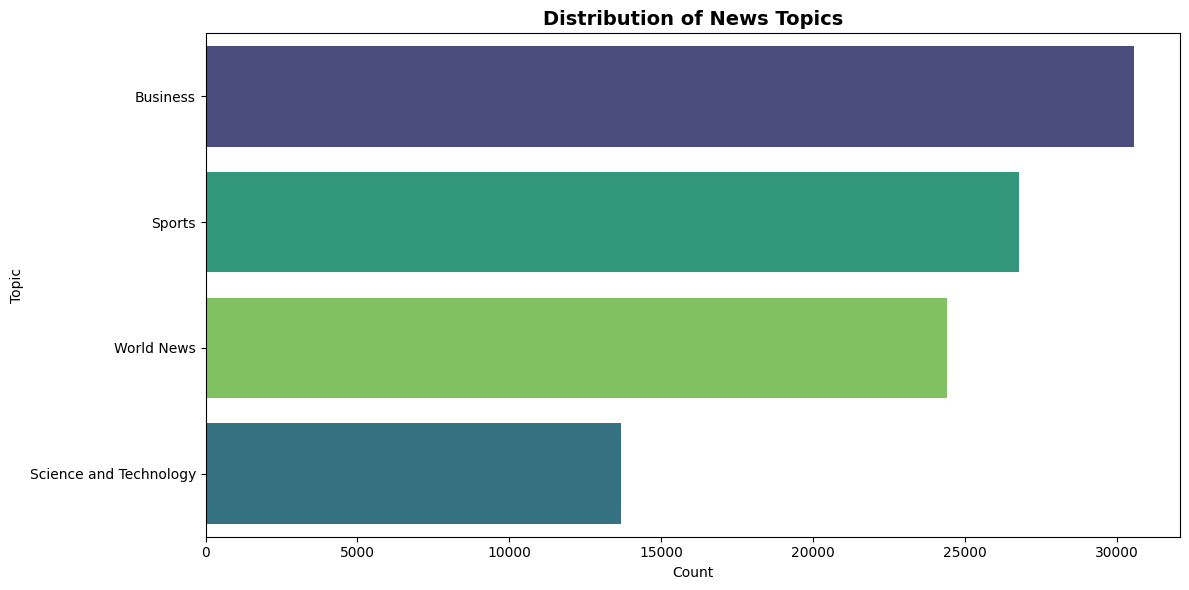


Topic Distribution:
News Topic
Business                  30563
Sports                    26773
World News                24415
Science and Technology    13689
Name: count, dtype: int64

Topic Percentages:
News Topic
Business                  32.02
Sports                    28.05
World News                25.58
Science and Technology    14.34
Name: count, dtype: float64


In [ ]:
# Class Distribution

plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='News Topic', order=train_df['News Topic'].value_counts().index,
              palette='viridis', hue='News Topic', legend=False)

plt.title('Distribution of News Topics', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

# Counts + %
topic_counts = train_df['News Topic'].value_counts()
print("\nTopic Distribution:")
print(topic_counts)

print("\nTopic Percentages:")
print((topic_counts / len(train_df) * 100).round(2))

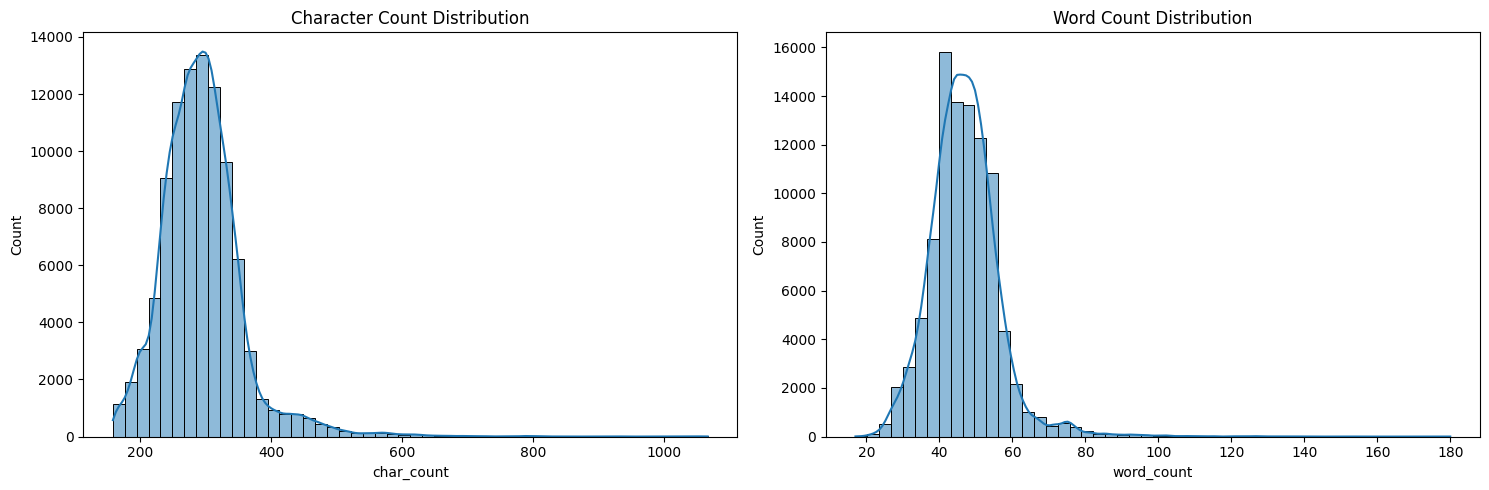


Text Length Stats:
Char Mean: 294.20
Word Mean: 46.88


In [ ]:
# Text Length Analysis

train_df['char_count'] = train_df['News Headline'].apply(len)
train_df['word_count'] = train_df['News Headline'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character count distribution
sns.histplot(train_df['char_count'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Character Count Distribution')

# Word count distribution
sns.histplot(train_df['word_count'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('Word Count Distribution')

plt.tight_layout()
plt.show()

print("\nText Length Stats:")
print(f"Char Mean: {train_df['char_count'].mean():.2f}")
print(f"Word Mean: {train_df['word_count'].mean():.2f}")

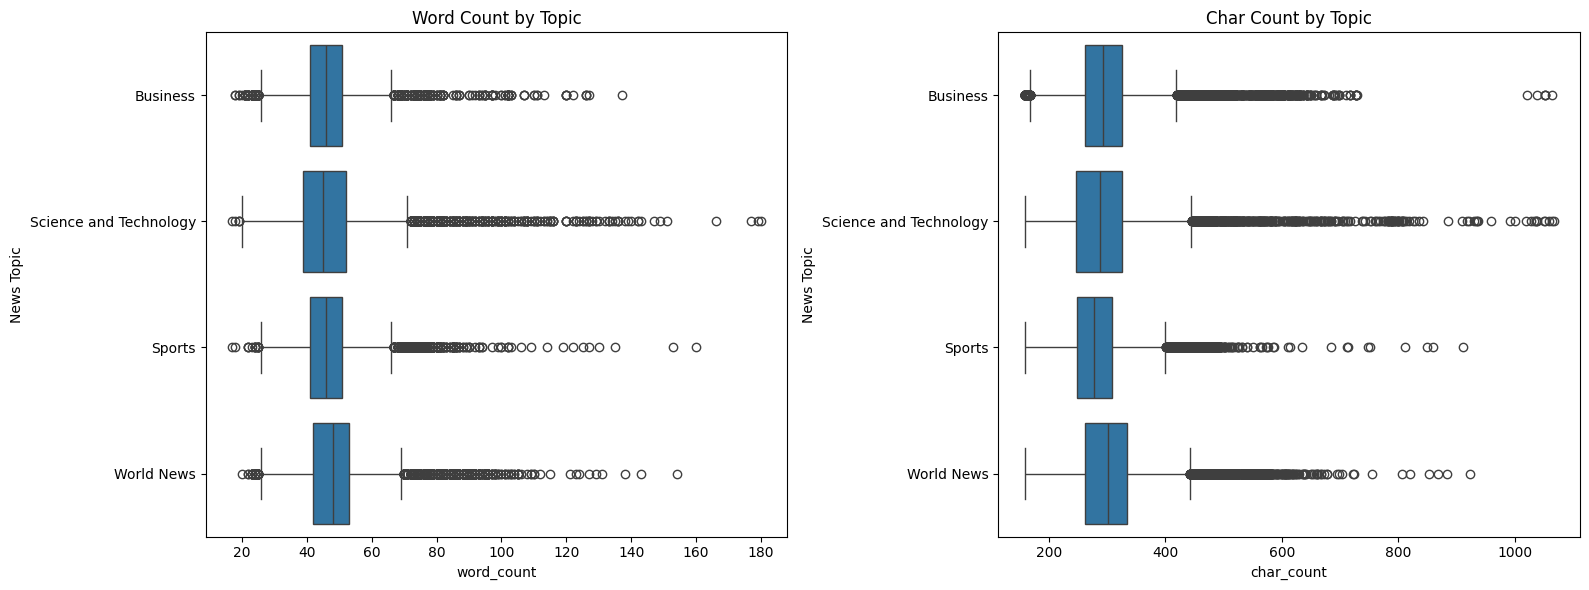

In [ ]:
# Text Length by Class — Boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# word count distribution per topic class
sns.boxplot(data=train_df, y='News Topic', x='word_count', ax=axes[0])
axes[0].set_title('Word Count by Topic')

# char count distribution per topic class
sns.boxplot(data=train_df, y='News Topic', x='char_count', ax=axes[1])
axes[1].set_title('Char Count by Topic')

plt.tight_layout()
plt.show()

In [ ]:
# Vocabulary Analysis

all_words = " ".join(train_df['News Headline'].astype(str)).lower().split()
word_freq  = Counter(all_words)

print("\nVOCAB ANALYSIS")
print(f"Total words:   {len(all_words)}")
print(f"Unique words:  {len(word_freq)}")
print(f"Richness:      {len(word_freq)/len(all_words):.4f}")


#Top 20 words

print("\nTop 20 Words:")
for w, c in word_freq.most_common(20):
    print(w, c)


VOCAB ANALYSIS
Total words:   4473946
Unique words:  128159
Richness:      0.0286

Top 20 Words:
<br> 286320
the 162432
news 97674
headlines: 95442
<html> 95440
<body> 95440
<b> 95440
</b> 95440
to 93979
a 85125
in 77712
of 76600
and 53899
on 46050
for 39758
- 31530
#39;s 25745
that 20931
as 20874
with 20647


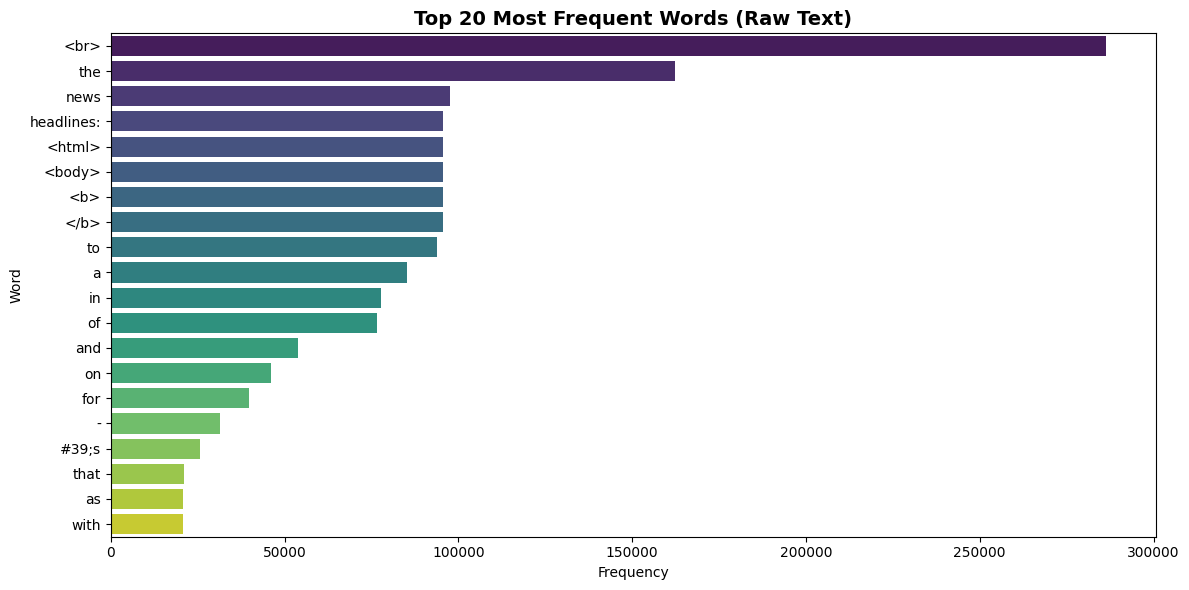

In [ ]:
# Visualize top words

top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='Frequency', y='Word', palette='viridis')
plt.title('Top 20 Most Frequent Words (Raw Text)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

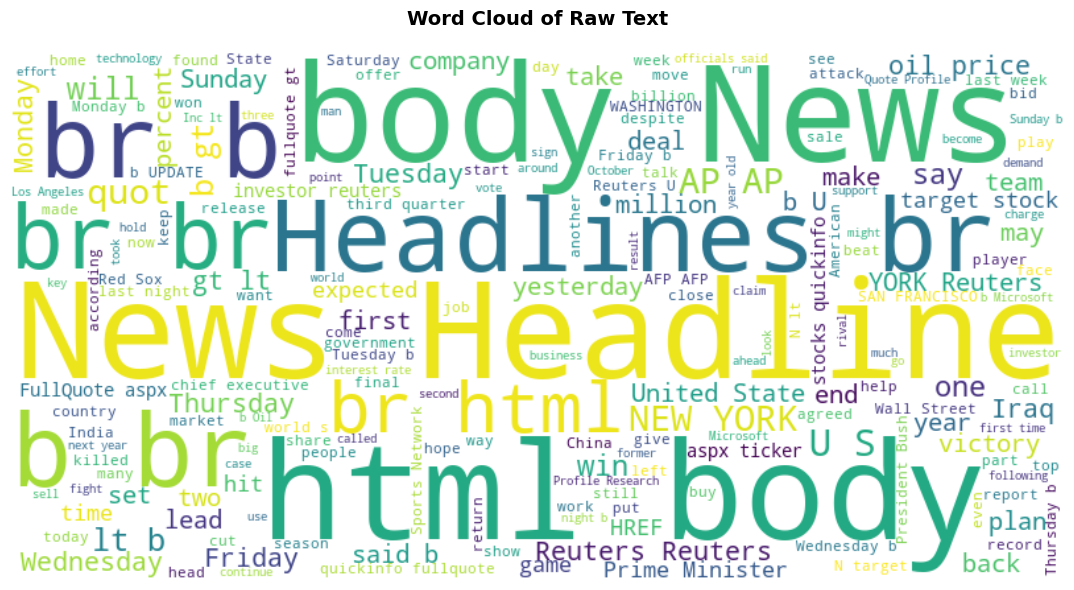

In [ ]:
# Word cloud of raw text (before stopword removal)
all_text = " ".join(train_df['News Headline'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Raw Text', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Class specific word analysis

for topic in train_df['News Topic'].unique():
    print("\n" + " "*30)
    print(f"TOP WORDS FOR: {topic}")
    print(" "*30)

    text = " ".join(train_df[train_df['News Topic'] == topic]['News Headline']).lower().split()
    freq = Counter(text)

    for word, count in freq.most_common(20):
        print(word, count)


                              
TOP WORDS FOR: Business
                              
<br> 91689
the 45247
news 31708
headlines: 30564
<html> 30563
<body> 30563
<b> 30563
</b> 30563
to 30523
a 25393
of 23077
in 22407
and 17179
on 16791
for 12274
its 9859
- 9274
#39;s 9117
as 8417
that 7301

                              
TOP WORDS FOR: Science and Technology
                              
<br> 41067
the 21578
to 14192
news 13971
<html> 13689
<body> 13689
headlines: 13689
<b> 13689
</b> 13689
of 12000
a 11989
and 8516
in 8070
for 5846
on 5448
that 4205
is 3597
its 3546
- 3477
new 3222

                              
TOP WORDS FOR: Sports
                              
<br> 80319
the 56168
news 27089
headlines: 26774
<html> 26773
<body> 26773
<b> 26773
</b> 26773
to 24369
a 23071
in 21306
of 18103
and 13949
for 12307
on 10884
#39;s 8486
at 8322
- 7803
with 7439
his 7041

                              
TOP WORDS FOR: World News
                              
<br> 73245
the 39439
in 25929

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams
bigram = CountVectorizer(ngram_range=(2,2), stop_words='english')  # only 2-word phrases
X2 = bigram.fit_transform(train_df['News Headline'])

bigram_train_df = pd.DataFrame({
    'Bigram': bigram.get_feature_names_out(),
    'Freq':   X2.sum(axis=0).A1                    # .A1 converts sparse matrix row to 1D array
}).sort_values(by='Freq', ascending=False).head(20)
print("\nTop Bigrams:")
print(bigram_train_df)


# Trigrams

trigram = CountVectorizer(ngram_range=(3,3), stop_words='english')
X3 = trigram.fit_transform(train_df['News Headline'])

trigram_train_df = pd.DataFrame({
    'Trigram': trigram.get_feature_names_out(),
    'Freq':    X3.sum(axis=0).A1
}).sort_values(by='Freq', ascending=False).head(20)

print("\nTop Trigrams:")
print(trigram_train_df)


Top Bigrams:
                  Bigram   Freq
632530    news headlines  95445
437403      headlines br  95443
138762             br br  95440
460054         html body  95440
129919         body news  95440
562083             lt gt   7332
70817              ap ap   5922
631805          new york   5849
789636   reuters reuters   3228
424718             gt lt   3118
649957        oil prices   2800
812944           said br   2391
1058082     york reuters   2142
990510     united states   2096
460077          http www   1958
721784    prime minister   1957
562086           lt href   1955
460002         href http   1955
788473       reuters com   1823
1049809     www investor   1819

Top Trigrams:
                            Trigram   Freq
1005957           news headlines br  95440
740570               html body news  95440
213316          body news headlines  95440
676170                     gt lt gt   2725
894515                     lt gt lt   2715
1272645                  said br br   239

In [ ]:
# Check stopwords presence
stop_words = set(stopwords.words('english'))


# Count how many words in each headline are stopwords
train_df['stopword_count'] = train_df['News Headline'].apply(
    lambda x: sum(1 for w in x.lower().split() if w in stop_words)
)

# Ratio
train_df['stopword_ratio'] = train_df['stopword_count'] / train_df['word_count']

print("Avg stopword ratio:", train_df['stopword_ratio'].mean())

Avg stopword ratio: 0.2405514397019134


In [ ]:
# Top Words AFTER removing stopwords

filtered_words = [
    w for w in " ".join(train_df['News Headline']).lower().split()
    if w not in stop_words
]

freq = Counter(filtered_words)

print("\nTop Clean Words:")
for w, c in freq.most_common(20):
    print(w, c)


Top Clean Words:
<br> 286320
news 97674
headlines: 95442
<html> 95440
<body> 95440
<b> 95440
</b> 95440
- 31530
#39;s 25745
new 16428
said 13887
(reuters) 10961
us 10501
two 7161
first 7063
oil 6907
(ap) 6289
-- 6219
ap 5989
u.s. 5795


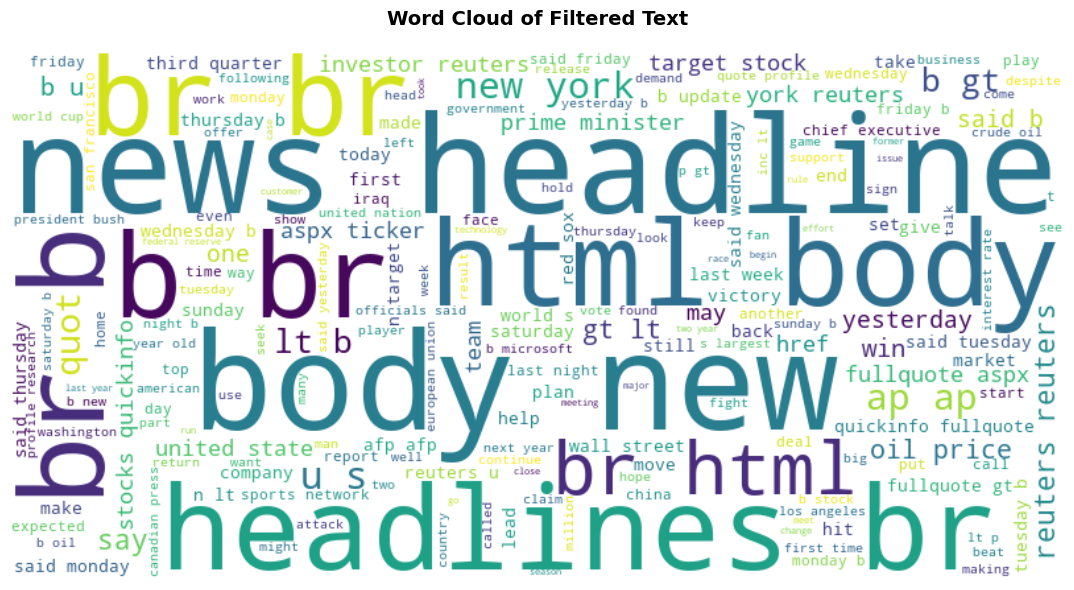

In [ ]:
# Word cloud after stopword removal

all_text = " ".join(filtered_words)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Filtered Text', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# CLASS BALANCE ANALYSIS

class_counts  = train_df['News Topic'].value_counts()

max_count     = class_counts.max()
min_count     = class_counts.min()
balance_ratio = min_count / max_count


print(f"Most common class:  {class_counts.index[0]} ({max_count} samples)")
print(f"Least common class: {class_counts.index[-1]} ({min_count} samples)")
print(f"Balance ratio (min/max): {balance_ratio:.2f}")


if balance_ratio < 0.5:
    print("⚠️ WARNING: Dataset is IMBALANCED. Consider using class weights or sampling techniques.")
else:
    print("✓ Dataset is relatively balanced.")

Most common class:  Business (30563 samples)
Least common class: Science and Technology (13689 samples)
Balance ratio (min/max): 0.45
⚠️ WARNING: Dataset is IMBALANCED. Consider using class weights or sampling techniques.


In [ ]:


# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
CUDA Version: 12.8


In [ ]:
# PREPROCESSING — TRAIN/VALIDATION SPLIT

X = train_df['News Headline']
y = train_df['News Topic']


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
porter     = PorterStemmer()
snowball   = SnowballStemmer("english")
lancaster  = LancasterStemmer()

# PREPROCESSING FUNCTIONS
# Extreme (Lancaster)

def extreme_preprocessing(text):
    text  = re.sub(r'<.*?>', '', str(text))            # remove HTML
    text  = re.sub(r'[^a-zA-Z0-9]', ' ', text)               # remove special chars
    text  = text.lower()

    words = text.split()
    words = [lancaster.stem(w) for w in words if w not in stop_words]

    return " ".join(words)

# Optimum (with different stemmers)

def preprocess_with_stemmer(text, stemmer):
    text  = re.sub(r'<.*?>', '', str(text))
    text  = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    text  = text.lower()

    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]

    return " ".join(words)

def preprocess_with_lemmatization(text):
    text  = re.sub(r'<.*?>', '', str(text))
    text  = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    text  = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

# APPLY PREPROCESSING

# Raw
X_train_raw  = X_train.copy()
X_val_raw    = X_val.copy()

# Extreme
X_train_extreme  = X_train.apply(extreme_preprocessing)
X_val_extreme    = X_val.apply(extreme_preprocessing)

# Optimum


X_train_porter   = X_train.apply(lambda x: preprocess_with_stemmer(x, porter))
X_val_porter     = X_val.apply(lambda x: preprocess_with_stemmer(x, porter))

X_train_snowball = X_train.apply(lambda x: preprocess_with_stemmer(x, snowball))
X_val_snowball   = X_val.apply(lambda x: preprocess_with_stemmer(x, snowball))

X_train_lancaster = X_train.apply(lambda x: preprocess_with_stemmer(x, lancaster))
X_val_lancaster   = X_val.apply(lambda x: preprocess_with_stemmer(x, lancaster))

X_train_lemma = X_train.apply(preprocess_with_lemmatization)
X_val_lemma   = X_val.apply(preprocess_with_lemmatization)

# EVALUATION FUNCTION (quick LR check)

def evaluate(X_train_text, X_val_text, y_train, y_val):
    tfidf       = TfidfVectorizer(max_features=5000)

    X_train_vec = tfidf.fit_transform(X_train_text)
    X_val_vec   = tfidf.transform(X_val_text)

    model       = LogisticRegression(max_iter=200)
    model.fit(X_train_vec, y_train)

    return accuracy_score(y_val, model.predict(X_val_vec))


# Run all preprocessing variants through the evaluation

results = {}

results['Raw (No Preprocessing)']  = evaluate(X_train_raw,      X_val_raw,      y_train, y_val)
results['Extreme (Lancaster)']      = evaluate(X_train_extreme,  X_val_extreme,  y_train, y_val)
results['Optimum - Lemmatization']  = evaluate(X_train_lemma,    X_val_lemma,    y_train, y_val)
results['Optimum - Porter']         = evaluate(X_train_porter,   X_val_porter,   y_train, y_val)
results['Optimum - Snowball']       = evaluate(X_train_snowball, X_val_snowball, y_train, y_val)
results['Optimum - Lancaster']      = evaluate(X_train_lancaster,X_val_lancaster,y_train, y_val)

print("\n" + "="*50)
print("PREPROCESSING COMPARISON RESULTS")
print("="*50)
for k, v in results.items():
    print(f"{k}: {v:.4f}")


#  BEST METHOD

best_method = max(results, key=results.get)
print("\nBest preprocessing method:", best_method)
print("Best accuracy:", results[best_method])


PREPROCESSING COMPARISON RESULTS
Raw (No Preprocessing): 0.9170
Extreme (Lancaster): 0.9166
Optimum - Lemmatization: 0.9194
Optimum - Porter: 0.9204
Optimum - Snowball: 0.9205
Optimum - Lancaster: 0.9166

Best preprocessing method: Optimum - Snowball
Best accuracy: 0.9205259849119866


In [ ]:
# Define all 3 preprocessing variants for the full dataset
# Raw
X_train_raw     = X_train.copy()
X_val_raw       = X_val.copy()

# Extreme (Lancaster)
X_train_extreme = X_train.apply(extreme_preprocessing)
X_val_extreme   = X_val.apply(extreme_preprocessing)

# Optimum (Snowball)
X_train_optimum = X_train.apply(lambda x: preprocess_with_stemmer(x, snowball))
X_val_optimum   = X_val.apply(lambda x: preprocess_with_stemmer(x, snowball))


PREPROCESSING_VARIANTS = {
    'Raw':     (X_train_raw,     X_val_raw),
    'Extreme': (X_train_extreme, X_val_extreme),
    'Optimum': (X_train_optimum, X_val_optimum),
}

print("Preprocessing variants ready:", list(PREPROCESSING_VARIANTS.keys()))

Preprocessing variants ready: ['Raw', 'Extreme', 'Optimum']


In [ ]:
# Label Encoding
le      = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)

num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {le.classes_}")

Classes (4): ['Business' 'Science and Technology' 'Sports' 'World News']


In [ ]:
# Apply all 3 preprocessing variants to the test set
X_test_raw     = test_df['News Headline'].copy()
X_test_extreme = test_df['News Headline'].apply(extreme_preprocessing)
X_test_optimum = test_df['News Headline'].apply(lambda x: preprocess_with_stemmer(x, snowball))


PREPROCESSING_TEST = {
    'Raw':     X_test_raw,
    'Extreme': X_test_extreme,
    'Optimum': X_test_optimum,
}

y_test_encoded = le.transform(test_df['News Topic'])
print("Test preprocessing variants ready.")

Test preprocessing variants ready.


In [ ]:
# Build TF-IDF features for each preprocessing variant

tfidf_features = {}
for prep_name, (X_tr, X_v) in PREPROCESSING_VARIANTS.items():
    print(f"\nFitting TF-IDF for '{prep_name}' ...")


    tfidf_v = TfidfVectorizer(max_features=20000,   # keep top 20k terms by frequency
                              ngram_range=(1, 2),   # include unigrams and bigrams
                              min_df=2,             # ignore terms appearing in fewer than 2 docs
                              max_df=0.95)           # ignore terms appearing in more than 95% of docs



    X_tr_tfidf   = tfidf_v.fit_transform(X_tr)
    X_val_tfidf  = tfidf_v.transform(X_v)
    X_test_tfidf = tfidf_v.transform(PREPROCESSING_TEST[prep_name])


     # Store vectorizer + matrices

    tfidf_features[prep_name] = {
        'tfidf':       tfidf_v,
        'X_tr_tfidf':  X_tr_tfidf,
        'X_val_tfidf': X_val_tfidf,
        'X_test_tfidf':X_test_tfidf,
    }
    print(f"  Train: {X_tr_tfidf.shape}  Val: {X_val_tfidf.shape}  Test: {X_test_tfidf.shape}")

print("\n✓ TF-IDF features ready for all variants.")


Fitting TF-IDF for 'Raw' ...
  Train: (76352, 20000)  Val: (19088, 20000)  Test: (12000, 20000)

Fitting TF-IDF for 'Extreme' ...
  Train: (76352, 20000)  Val: (19088, 20000)  Test: (12000, 20000)

Fitting TF-IDF for 'Optimum' ...
  Train: (76352, 20000)  Val: (19088, 20000)  Test: (12000, 20000)

✓ TF-IDF features ready for all variants.


In [ ]:

# Build Skip-gram Word2Vec for each preprocessing variant

w2v_models = {}

for prep_name, (X_tr, X_v) in PREPROCESSING_VARIANTS.items():
    print(f"\nTraining Skip-gram Word2Vec for '{prep_name}' ...")

    sentences = [text.split() for text in X_tr]

    w2v = Word2Vec(
        sentences,
        vector_size=100,  # embedding dimension
        window=5,         # context window 5 words left and right
        min_count=1,      # include words appearing at least once
        sg=1,             # sg=1 → Skip-gram
        workers=4,        # parallel threads
        epochs=10
    )


    w2v_models[prep_name] = w2v
    print(f"  Vocab size: {len(w2v.wv.index_to_key)}")

print("\n✓ Word2Vec models ready for all variants.")



Training Skip-gram Word2Vec for 'Raw' ...
  Vocab size: 136717

Training Skip-gram Word2Vec for 'Extreme' ...
  Vocab size: 31714

Training Skip-gram Word2Vec for 'Optimum' ...
  Vocab size: 36836

✓ Word2Vec models ready for all variants.


In [ ]:

# Tokenizer + Padding + Embedding matrices — pure Python/NumPy


MAX_LEN   = 50   # max sequence length
EMBED_DIM = 100  #  Word2Vec vector_size


class SimpleTokenizer:


    def __init__(self, num_words=30000, oov_token="<OOV>"):
        self.num_words  = num_words
        self.oov_token  = oov_token
        self.word_index = {oov_token: 1}
        self.num_words_ = num_words

    def fit_on_texts(self, texts):
        # Count word frequencies training texts

        freq = Counter()
        for text in texts:
            freq.update(str(text).split())

        # Keep only top (num_words - 2) words; assign incrementing integer indices
        for word, _ in freq.most_common(self.num_words - 2):
            if word not in self.word_index:
                self.word_index[word] = len(self.word_index) + 1  # 1-indexed

    def texts_to_sequences(self, texts):
        oov_idx = self.word_index[self.oov_token]  # fallback index for unknown words
        seqs = []
        for text in texts:

            #  unknown words get oov_idx
            seqs.append([self.word_index.get(w, oov_idx) for w in str(text).split()])
        return seqs


def pad_sequences_np(sequences, maxlen, padding='post', truncating='post'):
    """Replicates keras pad_sequences using NumPy."""
    out = np.zeros((len(sequences), maxlen), dtype=np.int64)  # 0 = padding token
    for i, seq in enumerate(sequences):

        # Truncate sequences longer than maxlen
        if len(seq) > maxlen:
            seq = seq[:maxlen] if truncating == 'post' else seq[-maxlen:]

        # Place sequence into output array
        if padding == 'post':
            out[i, :len(seq)] = seq           # pad zeros at the end
        else:
            out[i, maxlen - len(seq):] = seq  # pad zeros at the start
    return out


seq_features = {}

for prep_name, (X_tr, X_v) in PREPROCESSING_VARIANTS.items():
    print(f"\nBuilding sequences for '{prep_name}' ...")

    # Fit tokenizer on training text ONLY — val/test use the same vocab (no leakage)
    tokenizer = SimpleTokenizer(num_words=30000, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_tr)

    # Convert text to integer sequences then pad/truncate to MAX_LEN
    X_tr_seq   = pad_sequences_np(tokenizer.texts_to_sequences(X_tr),
                                   maxlen=MAX_LEN, padding='post', truncating='post')
    X_val_seq  = pad_sequences_np(tokenizer.texts_to_sequences(X_v),
                                   maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_seq = pad_sequences_np(tokenizer.texts_to_sequences(PREPROCESSING_TEST[prep_name]),
                                   maxlen=MAX_LEN, padding='post', truncating='post')

    # VOCAB_SIZE capped at num_words to match embedding layer input size
    VOCAB_SIZE   = min(tokenizer.num_words_, len(tokenizer.word_index)) + 1
    embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

    # Fill embedding matrix with Skip-gram vec

    w2v = w2v_models[prep_name]
    hit = 0
    for word, idx in tokenizer.word_index.items():
        if idx < VOCAB_SIZE and word in w2v.wv:
            embed_matrix[idx] = w2v.wv[word]  # copy pretrained vector into the right row
            hit += 1
    print(f"  Embed matrix: {embed_matrix.shape}  |  Words covered: {hit}/{VOCAB_SIZE-1}")


    seq_features[prep_name] = {
        'tokenizer':    tokenizer,
        'X_tr_seq':     X_tr_seq,
        'X_val_seq':    X_val_seq,
        'X_test_seq':   X_test_seq,
        'VOCAB_SIZE':   VOCAB_SIZE,
        'embed_matrix': embed_matrix,
    }

# Shared results collector
all_results = {prep: [] for prep in PREPROCESSING_VARIANTS}

print("\n✓ All setup complete — ready for experiments across all 3 variants!")


Building sequences for 'Raw' ...
  Embed matrix: (30000, 100)  |  Words covered: 29998/29999

Building sequences for 'Extreme' ...
  Embed matrix: (30000, 100)  |  Words covered: 29998/29999

Building sequences for 'Optimum' ...
  Embed matrix: (30000, 100)  |  Words covered: 29998/29999

✓ All setup complete — ready for experiments across all 3 variants!


In [ ]:
# HELPER — Confusion matrix plot


def plot_confusion_matrix(cm, model_name, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


Experiment 1: Random Forest + TF-IDF  [Raw]
  [1/12] n_est=100, max_d=15  Val=0.7446
    *** New best! ***
  [2/12] n_est=100, max_d=20  Val=0.7677
    *** New best! ***
  [3/12] n_est=100, max_d=25  Val=0.7870
    *** New best! ***
  [4/12] n_est=100, max_d=None  Val=0.8904
    *** New best! ***
  [5/12] n_est=200, max_d=15  Val=0.7505
  [6/12] n_est=200, max_d=20  Val=0.7688
  [7/12] n_est=200, max_d=25  Val=0.7869
  [8/12] n_est=200, max_d=None  Val=0.8906
    *** New best! ***
  [9/12] n_est=300, max_d=15  Val=0.7521
  [10/12] n_est=300, max_d=20  Val=0.7707
  [11/12] n_est=300, max_d=25  Val=0.7876
  [12/12] n_est=300, max_d=None  Val=0.8911
    *** New best! ***

Time: 41.1s | Best params: {'n_estimators': 300, 'max_depth': None} | Best val: 0.8911
TEST  Accuracy: 0.8523  |  F1 Macro: 0.8494
                        precision    recall  f1-score   support

              Business       0.79      0.88      0.83      3000
Science and Technology       0.92      0.68      0.78      30

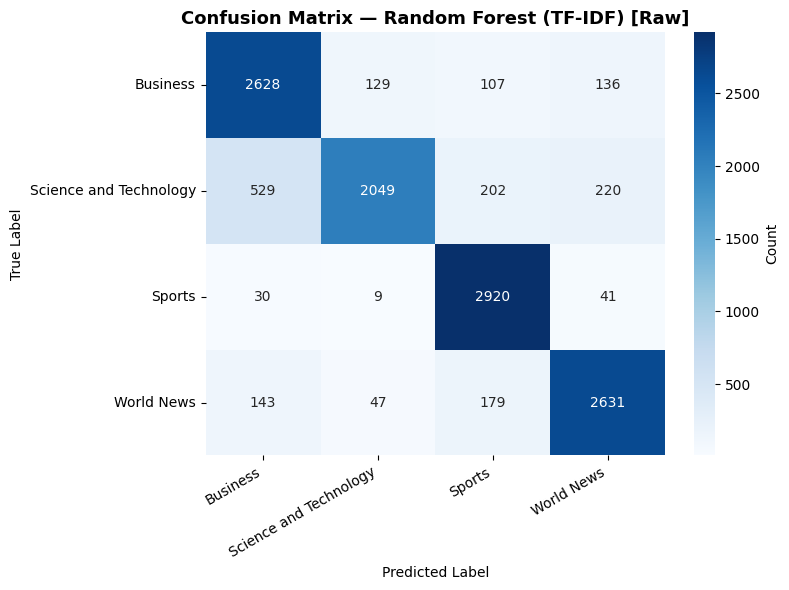


Experiment 1: Random Forest + TF-IDF  [Extreme]
  [1/12] n_est=100, max_d=15  Val=0.7707
    *** New best! ***
  [2/12] n_est=100, max_d=20  Val=0.7901
    *** New best! ***
  [3/12] n_est=100, max_d=25  Val=0.8062
    *** New best! ***
  [4/12] n_est=100, max_d=None  Val=0.9036
    *** New best! ***
  [5/12] n_est=200, max_d=15  Val=0.7735
  [6/12] n_est=200, max_d=20  Val=0.7915
  [7/12] n_est=200, max_d=25  Val=0.8092
  [8/12] n_est=200, max_d=None  Val=0.9047
    *** New best! ***
  [9/12] n_est=300, max_d=15  Val=0.7733
  [10/12] n_est=300, max_d=20  Val=0.7917
  [11/12] n_est=300, max_d=25  Val=0.8094
  [12/12] n_est=300, max_d=None  Val=0.9056
    *** New best! ***

Time: 30.6s | Best params: {'n_estimators': 300, 'max_depth': None} | Best val: 0.9056
TEST  Accuracy: 0.8708  |  F1 Macro: 0.8689
                        precision    recall  f1-score   support

              Business       0.81      0.90      0.85      3000
Science and Technology       0.93      0.73      0.81    

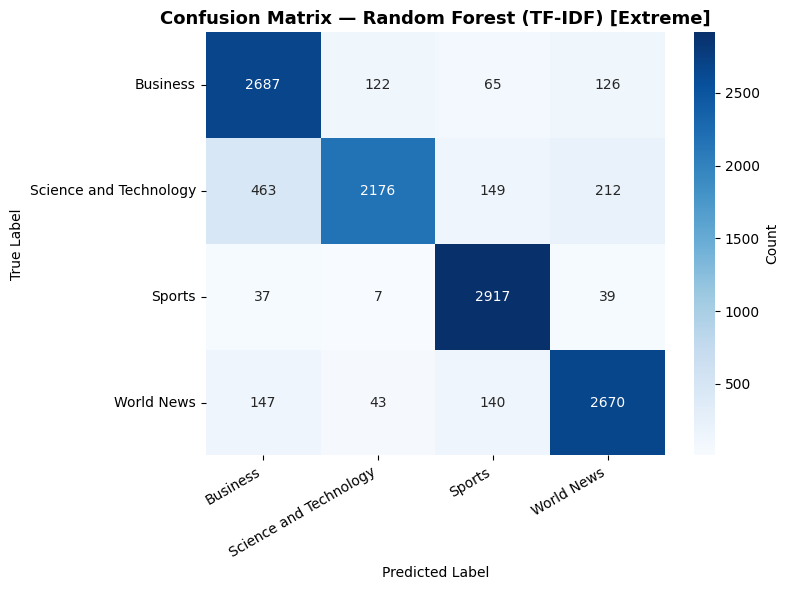


Experiment 1: Random Forest + TF-IDF  [Optimum]
  [1/12] n_est=100, max_d=15  Val=0.7724
    *** New best! ***
  [2/12] n_est=100, max_d=20  Val=0.7891
    *** New best! ***
  [3/12] n_est=100, max_d=25  Val=0.8049
    *** New best! ***
  [4/12] n_est=100, max_d=None  Val=0.9069
    *** New best! ***
  [5/12] n_est=200, max_d=15  Val=0.7728
  [6/12] n_est=200, max_d=20  Val=0.7925
  [7/12] n_est=200, max_d=25  Val=0.8064
  [8/12] n_est=200, max_d=None  Val=0.9065
  [9/12] n_est=300, max_d=15  Val=0.7721
  [10/12] n_est=300, max_d=20  Val=0.7901
  [11/12] n_est=300, max_d=25  Val=0.8068
  [12/12] n_est=300, max_d=None  Val=0.9068

Time: 30.1s | Best params: {'n_estimators': 100, 'max_depth': None} | Best val: 0.9069
TEST  Accuracy: 0.8728  |  F1 Macro: 0.8710
                        precision    recall  f1-score   support

              Business       0.81      0.90      0.85      3000
Science and Technology       0.93      0.73      0.82      3000
                Sports       0.89    

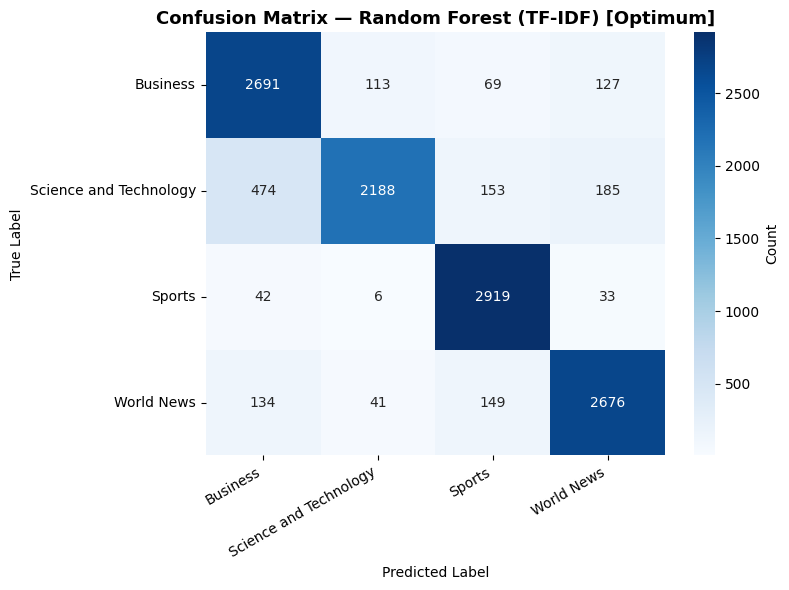

In [ ]:
# EXPERIMENT 1 — Random Forest + TF-IDF  (all 3 preprocessing variants)
# (Random Forest is CPU-only; no change needed here)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [15, 20, 25, None]
}

for prep_name in PREPROCESSING_VARIANTS:
    print("\n" + "="*60)
    print(f"Experiment 1: Random Forest + TF-IDF  [{prep_name}]")
    print("="*60)

    X_tr_tfidf   = tfidf_features[prep_name]['X_tr_tfidf']
    X_val_tfidf  = tfidf_features[prep_name]['X_val_tfidf']
    X_test_tfidf = tfidf_features[prep_name]['X_test_tfidf']

    best_rf_acc, best_rf_model, best_rf_params = 0, None, {}
    total   = len(param_grid['n_estimators']) * len(param_grid['max_depth'])
    cfg_num = 0
    start   = time.time()

    for n_est in param_grid['n_estimators']:
        for max_d in param_grid['max_depth']:
            cfg_num += 1

            rf = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=max_d,
                random_state=42,
                n_jobs=-1,          # use all CPU cores
                min_samples_split=5, # min samples to split a node (reduces overfitting)
                min_samples_leaf=2   # min samples at a leaf node (smooths tree)
            )



            rf.fit(X_tr_tfidf, y_train)
            val_acc = accuracy_score(y_val, rf.predict(X_val_tfidf))
            print(f"  [{cfg_num}/{total}] n_est={n_est}, max_d={max_d}  Val={val_acc:.4f}")

            # Track best config
            if val_acc > best_rf_acc:
                best_rf_acc, best_rf_model, best_rf_params = val_acc, rf, {'n_estimators': n_est, 'max_depth': max_d}
                print("    *** New best! ***")

    print(f"\nTime: {time.time()-start:.1f}s | Best params: {best_rf_params} | Best val: {best_rf_acc:.4f}")

    rf_pred = best_rf_model.predict(X_test_tfidf)
    rf_acc  = accuracy_score(y_test_encoded, rf_pred)
    rf_f1   = f1_score(y_test_encoded, rf_pred, average='macro')
    rf_cm   = confusion_matrix(y_test_encoded, rf_pred)


    print(f"TEST  Accuracy: {rf_acc:.4f}  |  F1 Macro: {rf_f1:.4f}")
    print(classification_report(y_test_encoded, rf_pred, target_names=le.classes_))
    plot_confusion_matrix(rf_cm, f'Random Forest (TF-IDF) [{prep_name}]', le.classes_)


    all_results[prep_name].append({
        'model': 'Random Forest (TF-IDF)', 'accuracy': rf_acc, 'f1_macro': rf_f1,
        'cm': rf_cm, 'best_params': best_rf_params,
        'labels': y_test_encoded, 'predictions': rf_pred
    })


Experiment 2: DNN + TF-IDF  [Raw]
  [1/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9292
    *** New best! ***
  [2/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9318
    *** New best! ***
  [3/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9347
    *** New best! ***
  [4/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.5, 'batch_size': 128}
    Best Val: 0.9348
    *** New best! ***
  [5/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9318
  [6/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9312
  [7/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9341
  [8/9] {'hidden_dims': [2048, 1024, 512, 256, 128], 'lr': 0.001, 'dropout': 

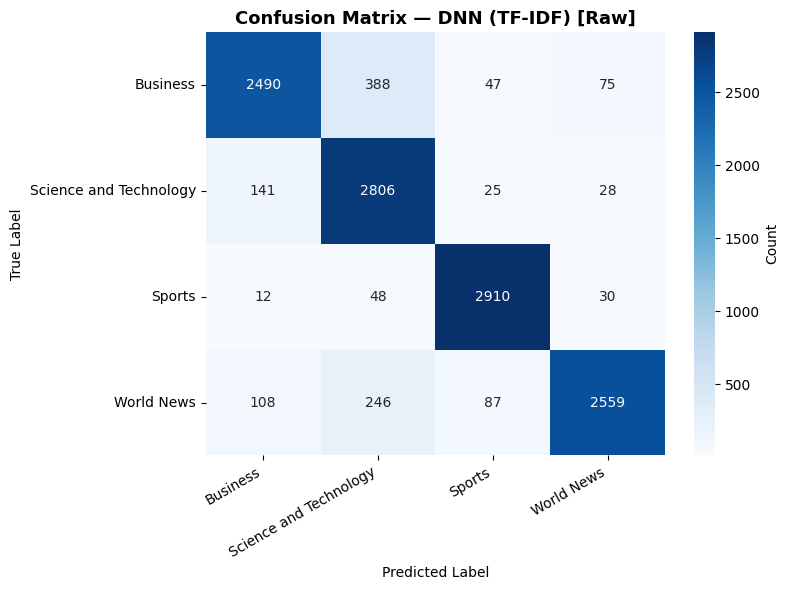


Experiment 2: DNN + TF-IDF  [Extreme]
  [1/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9350
    *** New best! ***
  [2/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9386
    *** New best! ***
  [3/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9381
  [4/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.5, 'batch_size': 128}
    Best Val: 0.9360
  [5/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9368
  [6/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9346
  [7/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9385
  [8/9] {'hidden_dims': [2048, 1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9

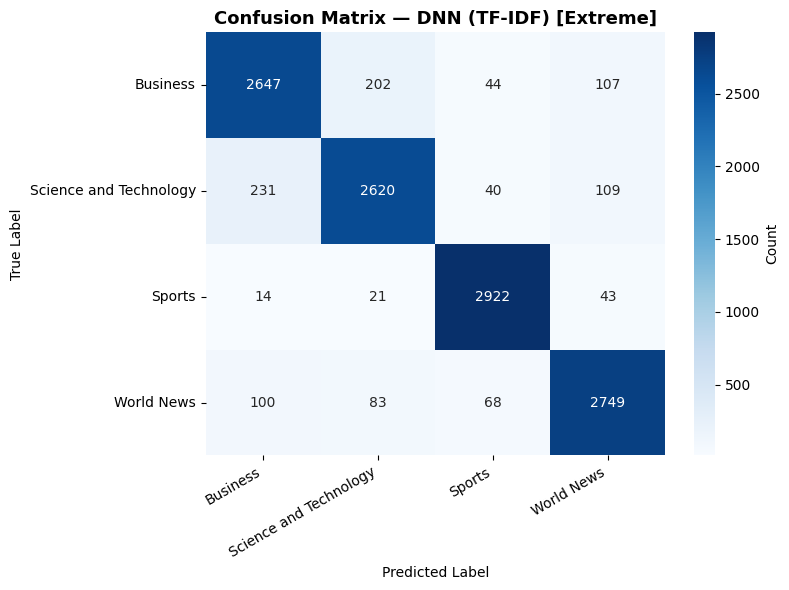


Experiment 2: DNN + TF-IDF  [Optimum]
  [1/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9369
    *** New best! ***
  [2/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9383
    *** New best! ***
  [3/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9379
  [4/9] {'hidden_dims': [512, 256, 128, 64], 'lr': 0.001, 'dropout': 0.5, 'batch_size': 128}
    Best Val: 0.9343
  [5/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9397
    *** New best! ***
  [6/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64}
    Best Val: 0.9388
  [7/9] {'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}
    Best Val: 0.9392
  [8/9] {'hidden_dims': [2048, 1024, 512, 256, 128], 'lr': 0.001, 'dropout': 0.3, 'batch_size':

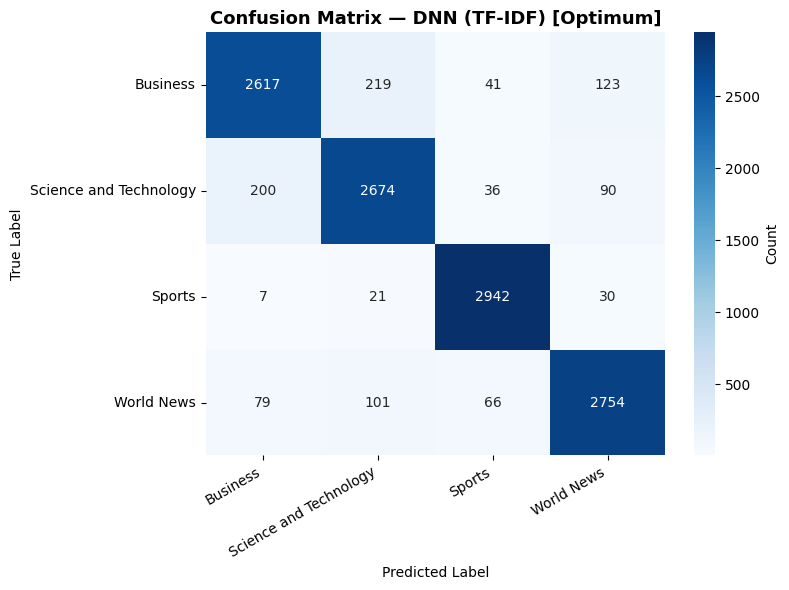

In [ ]:

# EXPERIMENT 2 — Deep Neural Network + TF-IDF

class DNNModel(nn.Module):

    def __init__(self, input_dim, hidden_dims, dropout, num_classes):
        super().__init__()
        layers = []
        in_dim = input_dim  # first layer input  TF-IDF vector size

        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.ReLU(),
                nn.BatchNorm1d(h),   # normalize activations per batch, stabilizes training
                nn.Dropout(dropout), #  prevent overfitting
            ]
            in_dim = h
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_pytorch_model(model, X_tr, y_tr, X_val, y_va,
                         lr, batch_size, epochs=20, patience=3):

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()


    if isinstance(X_tr, np.ndarray):
        X_tr_t = torch.tensor(X_tr,       dtype=torch.float32)
        X_va_t = torch.tensor(X_val,      dtype=torch.float32)

    else:  # sparse matrix (from TfidfVectorizer)
        X_tr_t = torch.tensor(X_tr.toarray(),  dtype=torch.float32)
        X_va_t = torch.tensor(X_val.toarray(), dtype=torch.float32)

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)  # integer class labels
    y_va_t = torch.tensor(y_va, dtype=torch.long)

    # Wrap training data in DataLoader for mini-batch iteration
    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  # shuffle each epoch

    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0      # early stopping counter

    for epoch in range(epochs):
        # ── Training pass ──
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()          #  gradients from prev
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Validation pass
        model.eval()
        with torch.no_grad():
            logits  = model(X_va_t.to(device))
            preds   = logits.argmax(dim=1).cpu().numpy()  # highest logit = predicted class
            val_acc = accuracy_score(y_va, preds)

        # Save best weights and reset patience counter if improved
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}  # deep copy to CPU
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:  # stop if no improv
                break

    model.load_state_dict(best_state)  #  best weights
    return best_val_acc


def predict_pytorch(model, X, batch_size=512):

    model.eval()
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # convert sparse matrix to dense for tensor conversion
    X_t = torch.tensor(X, dtype=torch.float32)
    all_preds = []
    with torch.no_grad():
        # Process in batches to avoid OOM on large test sets
        for i in range(0, len(X_t), batch_size):
            batch = X_t[i:i+batch_size].to(device)
            all_preds.append(model(batch).argmax(dim=1).cpu().numpy())
    return np.concatenate(all_preds)  # merge all batch predictions into one array


# Hyperparameter grid — varies architecture depth/width, lr, dropout, batch size

dnn_configs = [
    {'hidden_dims': [512, 256, 128, 64],         'lr': 0.001,  'dropout': 0.3, 'batch_size': 64},
    {'hidden_dims': [512, 256, 128, 64],         'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64},  # lower lr
    {'hidden_dims': [512, 256, 128, 64],         'lr': 0.001,  'dropout': 0.2, 'batch_size': 32},  # less dropout, smaller batch
    {'hidden_dims': [512, 256, 128, 64],         'lr': 0.001,  'dropout': 0.5, 'batch_size': 128}, # heavy dropout
    {'hidden_dims': [1024, 512, 256, 128],       'lr': 0.001,  'dropout': 0.3, 'batch_size': 64},  # wider network
    {'hidden_dims': [1024, 512, 256, 128],       'lr': 0.0005, 'dropout': 0.3, 'batch_size': 64},
    {'hidden_dims': [1024, 512, 256, 128],       'lr': 0.001,  'dropout': 0.2, 'batch_size': 32},
    {'hidden_dims': [2048, 1024, 512, 256, 128], 'lr': 0.001,  'dropout': 0.3, 'batch_size': 64},  # deepest config
    {'hidden_dims': [2048, 1024, 512, 256, 128], 'lr': 0.0005, 'dropout': 0.2, 'batch_size': 64},
]

for prep_name in PREPROCESSING_VARIANTS:
    print("\n" + "="*60)
    print(f"Experiment 2: DNN + TF-IDF  [{prep_name}]")
    print("="*60)

    # Pull precomputed TF-IDF matrices for this preprocessing variant
    X_tr_tfidf   = tfidf_features[prep_name]['X_tr_tfidf']
    X_val_tfidf  = tfidf_features[prep_name]['X_val_tfidf']
    X_test_tfidf = tfidf_features[prep_name]['X_test_tfidf']
    INPUT_DIM    = X_tr_tfidf.shape[1]   # TF-IDF vocab size

    best_dnn_val, best_dnn_model, best_dnn_cfg = 0, None, None

    # train each config and track the best by val accuracy

    for i, cfg in enumerate(dnn_configs, 1):
        print(f"  [{i}/{len(dnn_configs)}] {cfg}")
        model   = DNNModel(INPUT_DIM, cfg['hidden_dims'], cfg['dropout'], num_classes)
        val_acc = train_pytorch_model(
            model,
            X_tr_tfidf, y_train,
            X_val_tfidf, y_val,
            lr=cfg['lr'], batch_size=cfg['batch_size'],
            epochs=20, patience=3
        )
        print(f"    Best Val: {val_acc:.4f}")
        if val_acc > best_dnn_val:
            best_dnn_val, best_dnn_model, best_dnn_cfg = val_acc, model, cfg
            print("    *** New best! ***")

    print(f"\nBest config: {best_dnn_cfg}  |  Best val: {best_dnn_val:.4f}")

    # Evaluate best model on held-out test set

    dnn_pred = predict_pytorch(best_dnn_model, X_test_tfidf)
    dnn_acc  = accuracy_score(y_test_encoded, dnn_pred)
    dnn_f1   = f1_score(y_test_encoded, dnn_pred, average='macro')
    dnn_cm   = confusion_matrix(y_test_encoded, dnn_pred)
    print(f"TEST  Accuracy: {dnn_acc:.4f}  |  F1 Macro: {dnn_f1:.4f}")
    print(classification_report(y_test_encoded, dnn_pred, target_names=le.classes_))
    plot_confusion_matrix(dnn_cm, f'DNN (TF-IDF) [{prep_name}]', le.classes_)

    # Append results to shared collector for final comparison cell
    all_results[prep_name].append({
        'model': 'DNN (TF-IDF)', 'accuracy': dnn_acc, 'f1_macro': dnn_f1,
        'cm': dnn_cm, 'best_params': best_dnn_cfg,
        'labels': y_test_encoded, 'predictions': dnn_pred
    })

In [ ]:

# SHARED HELPER — Build any RNN / GRU / LSTM model in PyTorch

class RNNClassifier(nn.Module):

    def __init__(self, rnn_type, vocab_size, embed_dim, embed_matrix,
                 hidden_dim, num_layers, dropout, bidirectional, num_classes):
        super().__init__()

        # ── Embedding layer ──
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Load pretrained Skip-gram vec
        self.embedding.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True  # trainable

        # RNN layer
        rnn_map = {'SimpleRNN': nn.RNN, 'GRU': nn.GRU, 'LSTM': nn.LSTM}
        RNNCls  = rnn_map[rnn_type]

        self.rnn = RNNCls(
            embed_dim, hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,          # input shape: (batch, seq_len, embed_dim)
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )
        self.is_lstm       = (rnn_type == 'LSTM')   # LSTM returns extra cell state
        self.bidirectional = bidirectional


        rnn_out_dim = hidden_dim * (2 if bidirectional else 1)

        # ── Classifier head ──
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(rnn_out_dim, 128)  # compress RNN output to 128
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(128, num_classes)  # class logits

    def forward(self, x):
        emb = self.embedding(x)   # embed  token to sequence
        out = self.rnn(emb)

        if self.is_lstm:
            out = out[0]
        else:
            out = out[0]   #

        # Use only the last time-step as the sequence rep
        out = out[:, -1, :]             # (B, rnn_out_dim)
        out = self.drop(out)
        out = self.relu(self.fc1(out))
        return self.fc2(out)            # CrossEntropyLoss


def train_seq_model(model, X_tr_seq, y_tr, X_val_seq, y_va,
                    batch_size=64, epochs=15, patience=3, lr=0.001):

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Sequences
    X_tr_t = torch.tensor(X_tr_seq,  dtype=torch.long)
    y_tr_t = torch.tensor(y_tr,      dtype=torch.long)
    X_va_t = torch.tensor(X_val_seq, dtype=torch.long)
    y_va_t = torch.tensor(y_va,      dtype=torch.long)

    # Wrap training data for mini-batch iteration
    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  # shuffle each epoch

    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for epoch in range(epochs):
        # Training pass
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()                 # backprop
            optimizer.step()

        # Validation pass
        model.eval()
        with torch.no_grad():              # no gradient track for eval
            logits  = model(X_va_t.to(device))
            preds   = logits.argmax(dim=1).cpu().numpy()
            val_acc = accuracy_score(y_va, preds)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}  # deep copy to CPU
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:  # stop early
                break

    model.load_state_dict(best_state)  # best checkpoint
    return best_val_acc


def predict_seq(model, X_seq, batch_size=512):

    model.eval()
    X_t = torch.tensor(X_seq, dtype=torch.long)
    all_preds = []
    with torch.no_grad():


        for i in range(0, len(X_t), batch_size):
            batch = X_t[i:i+batch_size].to(device)
            all_preds.append(model(batch).argmax(dim=1).cpu().numpy())

    return np.concatenate(all_preds)  # merge all batch pred


def tune_rnn_for_variant(exp_name, rnn_type, prep_name, bidirectional=False):

    from itertools import product

    # padded seq

    X_tr_seq     = seq_features[prep_name]['X_tr_seq']
    X_val_seq    = seq_features[prep_name]['X_val_seq']
    X_test_seq   = seq_features[prep_name]['X_test_seq']
    VOCAB_SIZE   = seq_features[prep_name]['VOCAB_SIZE']
    embed_matrix = seq_features[prep_name]['embed_matrix']

    # Define hyperparameter search space
    hidden_dims  = [64, 128]
    lrs          = [0.001, 0.0005]
    num_layers_l = [1, 2]
    dropouts     = [0.2, 0.3]

    # all combinations: 2×2×2×2 = 16 configs
    configs      = list(product(hidden_dims, lrs, num_layers_l, dropouts))
    print(f"  Total configs: {len(configs)}")

    best_val, best_model, best_cfg = 0, None, None

    for i, (hd, lr, nl, dr) in enumerate(configs, 1):
        cfg   = {'hidden_dim': hd, 'lr': lr, 'num_layers': nl, 'dropout': dr}
        model = RNNClassifier(
            rnn_type=rnn_type,
            vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
            embed_matrix=embed_matrix,
            hidden_dim=hd, num_layers=nl,
            dropout=dr, bidirectional=bidirectional,
            num_classes=num_classes
        )
        val_acc = train_seq_model(
            model, X_tr_seq, y_train, X_val_seq, y_val,
            batch_size=64, epochs=15, patience=3, lr=lr
        )
        print(f"    [{i}/{len(configs)}] {cfg}  Val={val_acc:.4f}")
        if val_acc > best_val:
            best_val, best_model, best_cfg = val_acc, model, cfg
            print("      *** New best! ***")

    print(f"  Best config: {best_cfg}  |  Best val: {best_val:.4f}")

    # Evaluate best config on held-out test set

    preds = predict_seq(best_model, X_test_seq)
    acc   = accuracy_score(y_test_encoded, preds)
    f1    = f1_score(y_test_encoded, preds, average='macro')
    cm    = confusion_matrix(y_test_encoded, preds)
    print(f"  TEST  Accuracy: {acc:.4f}  |  F1 Macro: {f1:.4f}")
    print(classification_report(y_test_encoded, preds, target_names=le.classes_))
    plot_confusion_matrix(cm, f'{exp_name} [{prep_name}]', le.classes_)

    # shared results
    all_results[prep_name].append({
        'model': exp_name, 'accuracy': acc, 'f1_macro': f1,
        'cm': cm, 'best_params': best_cfg,
        'labels': y_test_encoded, 'predictions': preds
    })
    return best_model


RNN Experiments — Preprocessing: [Raw]

  ── SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9086
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.5757
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.5848
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.5867
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.8661
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.8889
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.8715
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9087
      *** New best! ***
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.6069
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'd

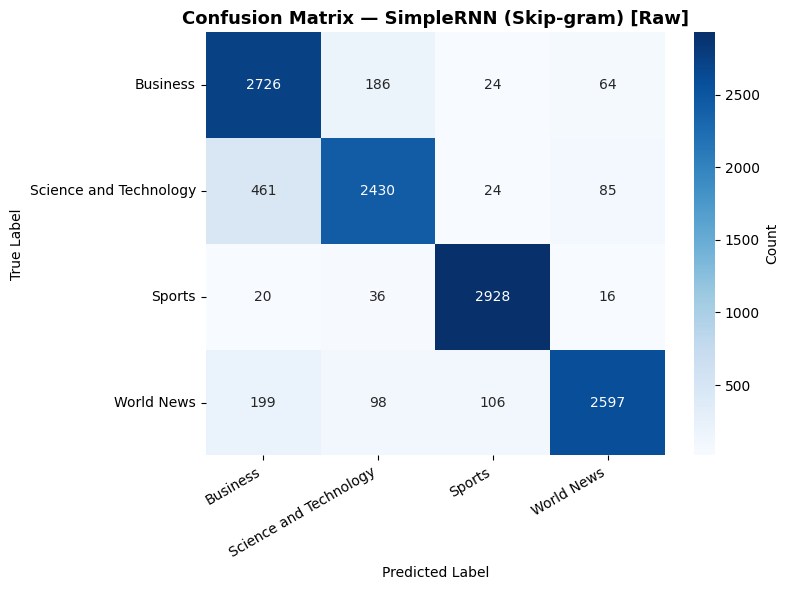


  ── GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9380
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9351
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9370
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9351
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9370
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9353
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9358
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9348
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9380
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9379
    [11/16] {'hidden_dim': 128, 'lr': 0.001,

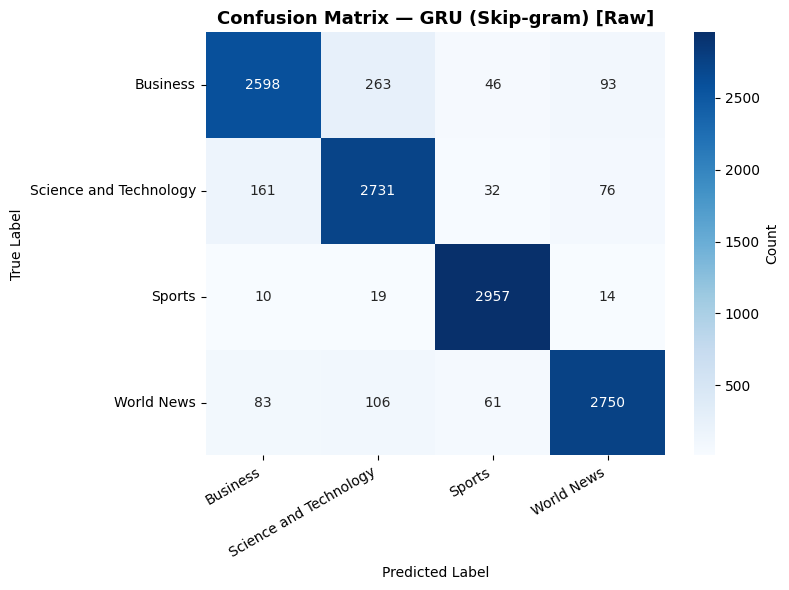


  ── LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9332
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9326
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9320
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9337
      *** New best! ***
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9359
      *** New best! ***
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9339
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9328
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9344
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9346
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.

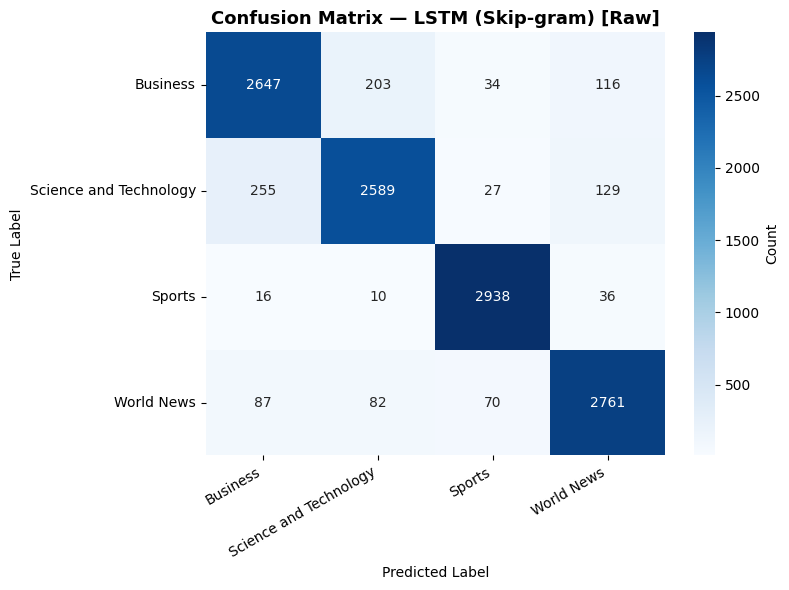


  ── Bidirectional SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.6246
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.6500
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.6231
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.7881
      *** New best! ***
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9081
      *** New best! ***
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.8912
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.8937
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.8708
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.4188
    [10/16] {'hidden_dim': 128, 'lr': 0.00

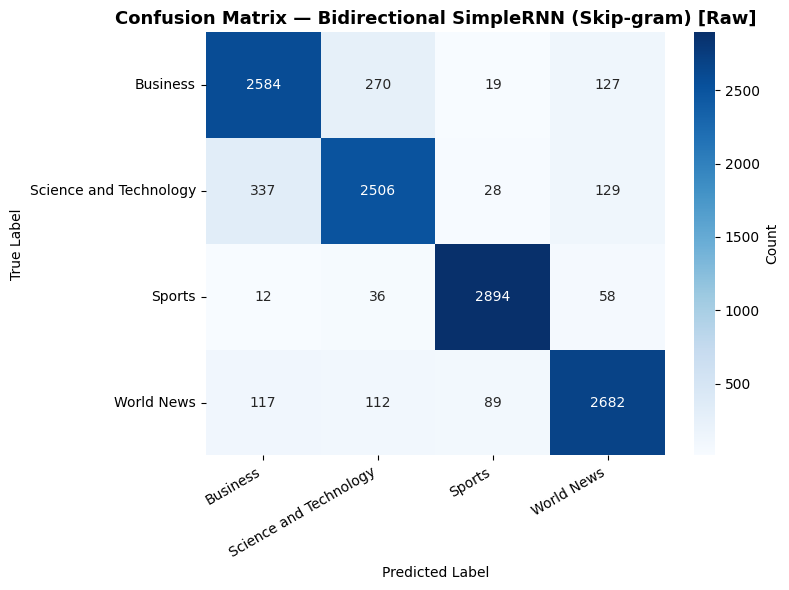


  ── Bidirectional GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9362
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9379
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9399
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9393
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9358
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9364
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9371
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9394
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9372
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout':

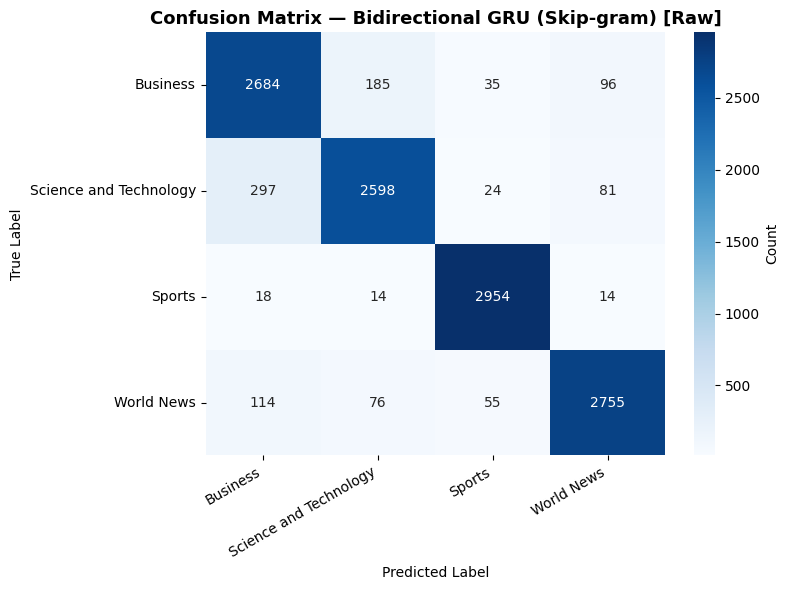


  ── Bidirectional LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9350
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9336
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9339
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9365
      *** New best! ***
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9328
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9348
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9345
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9372
      *** New best! ***
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9336
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout'

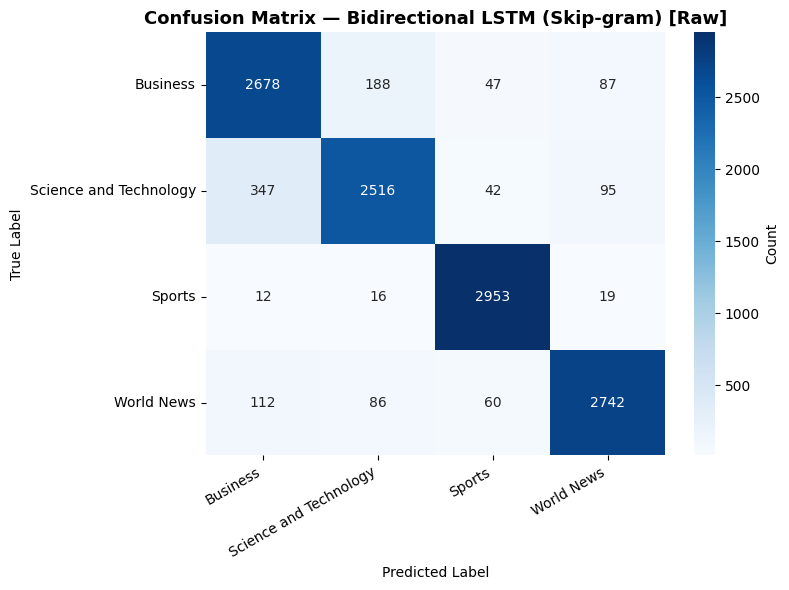


RNN Experiments — Preprocessing: [Extreme]

  ── SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9071
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.5052
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.5553
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.3582
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.5714
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.5824
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.6658
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.5641
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.8967
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0

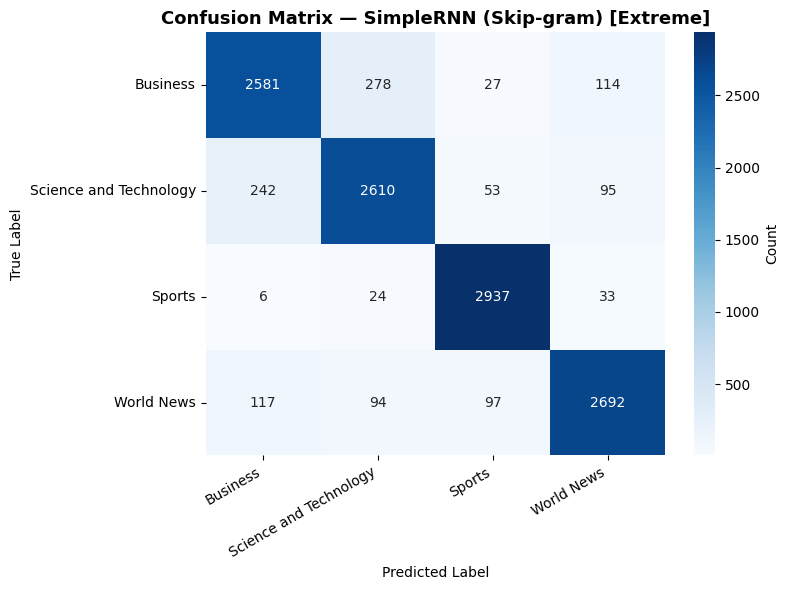


  ── GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9332
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9351
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9315
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9326
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9318
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9308
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9301
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9321
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9346
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9327
    [11/16] {'hidden

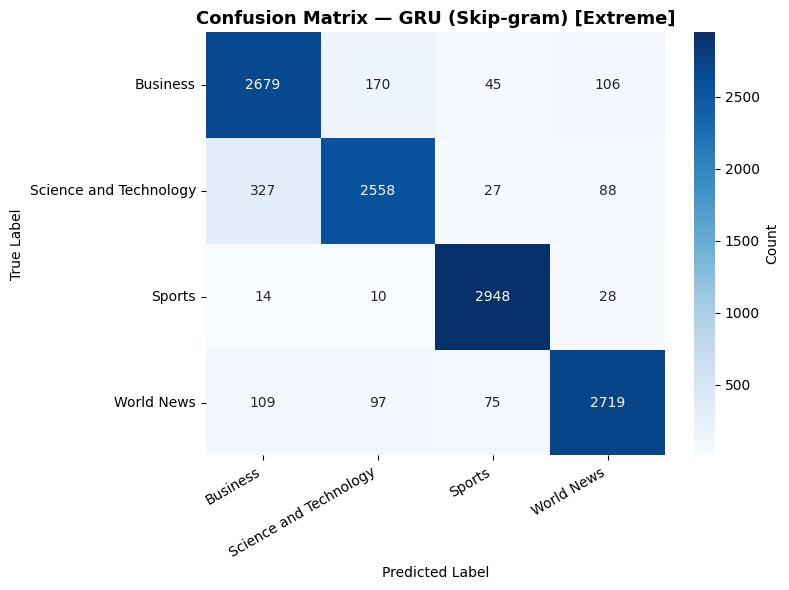


  ── LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9311
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9293
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9283
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9289
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9306
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9273
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9306
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9300
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9328
      *** New best! ***
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9298
    [11/16] {'hidde

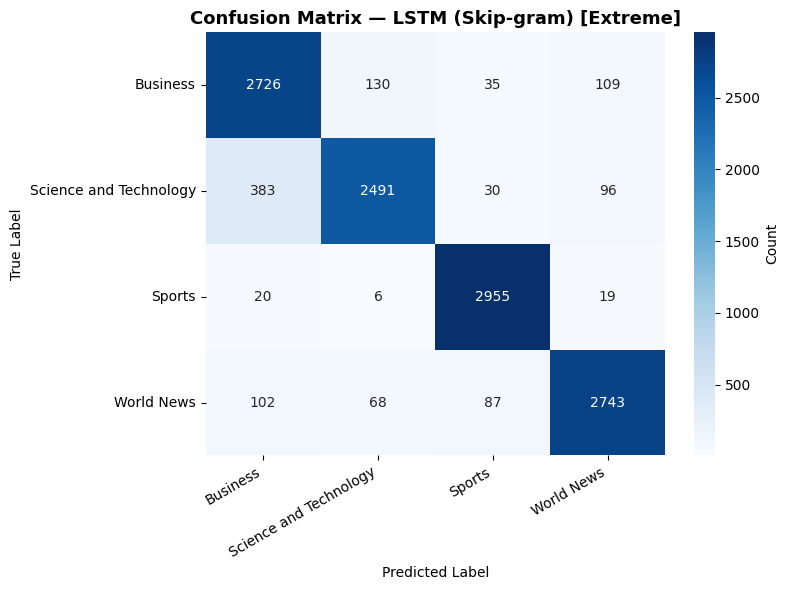


  ── Bidirectional SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.3417
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.3255
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.5111
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.3971
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.5036
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.8613
      *** New best! ***
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.5771
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.8062
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.3353
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dro

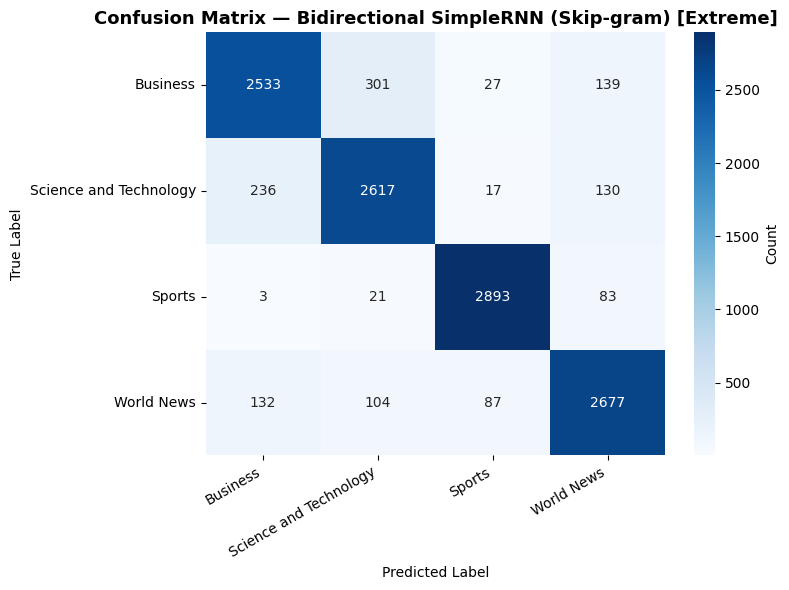


  ── Bidirectional GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9345
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9296
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9326
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9335
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9307
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9301
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9317
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9326
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9332
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9305
    [11/16] {'hidden_dim': 128

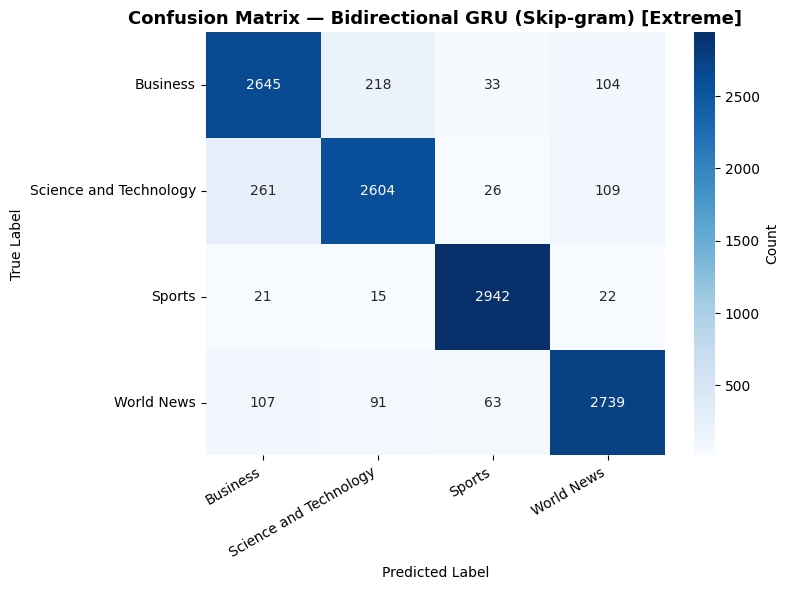


  ── Bidirectional LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9290
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9305
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9321
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9279
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9305
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9295
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9273
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9321
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9313
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout'

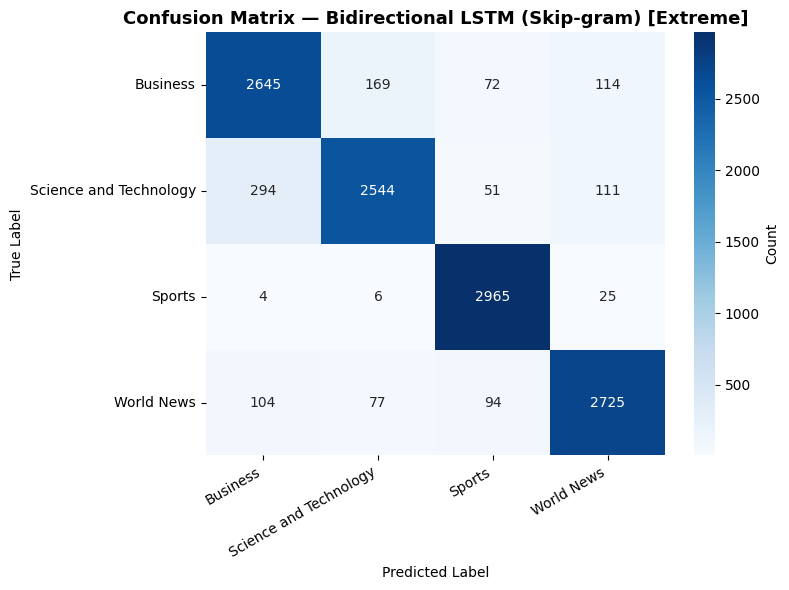


RNN Experiments — Preprocessing: [Optimum]

  ── SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.5627
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.5802
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.8371
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.3203
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.5788
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.5569
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.3205
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.5834
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.8910
      *** New best! ***
    [10/16] 

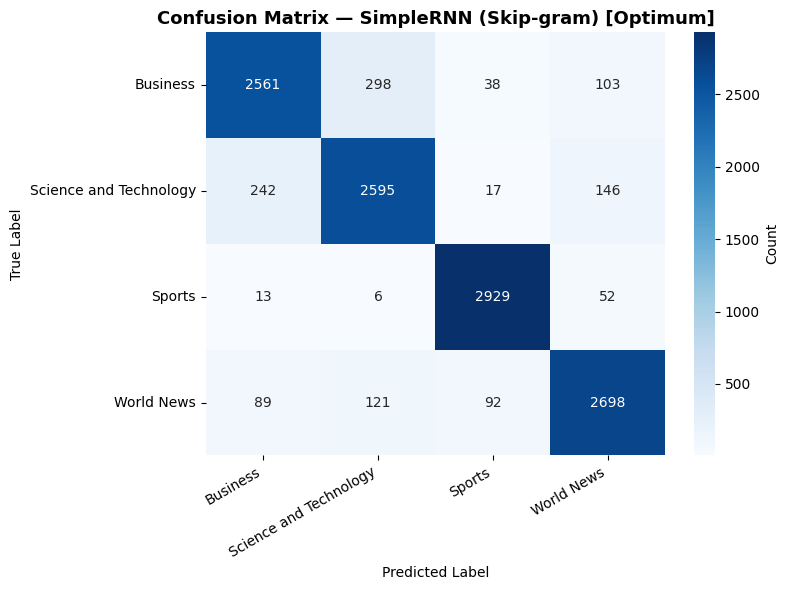


  ── GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9331
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9346
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9338
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9340
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9328
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9315
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9326
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9322
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9332
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9362
      *** New best! 

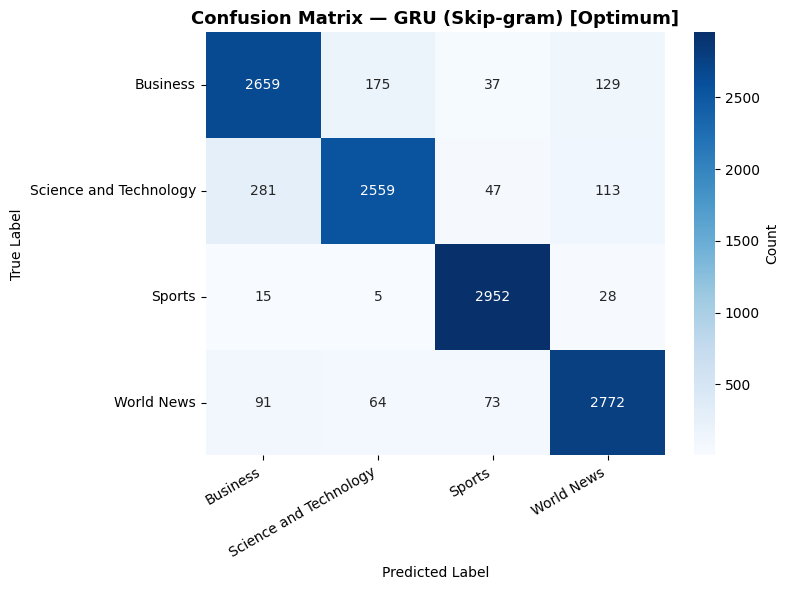


  ── LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9326
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9319
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9327
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9300
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9327
      *** New best! ***
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9321
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9337
      *** New best! ***
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9332
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9321
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1,

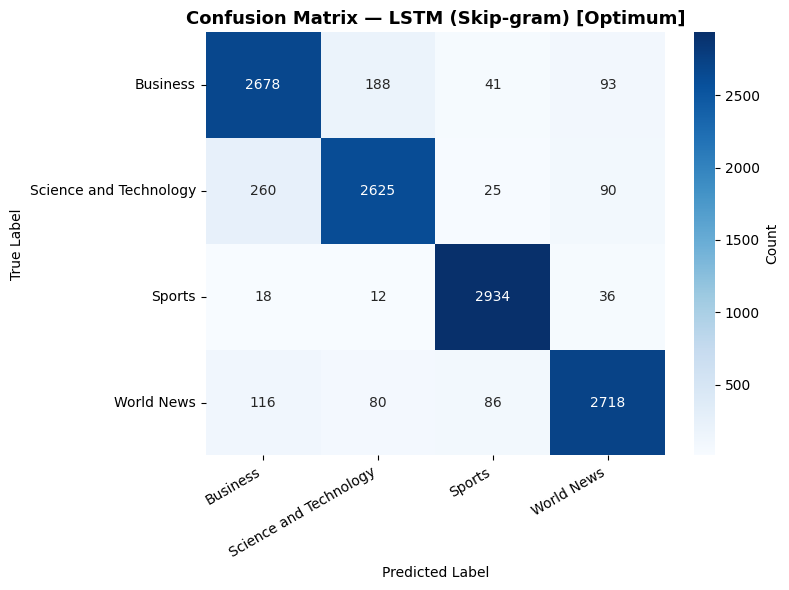


  ── Bidirectional SimpleRNN (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.3465
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.4911
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.5444
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.5218
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.5761
      *** New best! ***
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.5813
      *** New best! ***
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.6347
      *** New best! ***
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.5811
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0

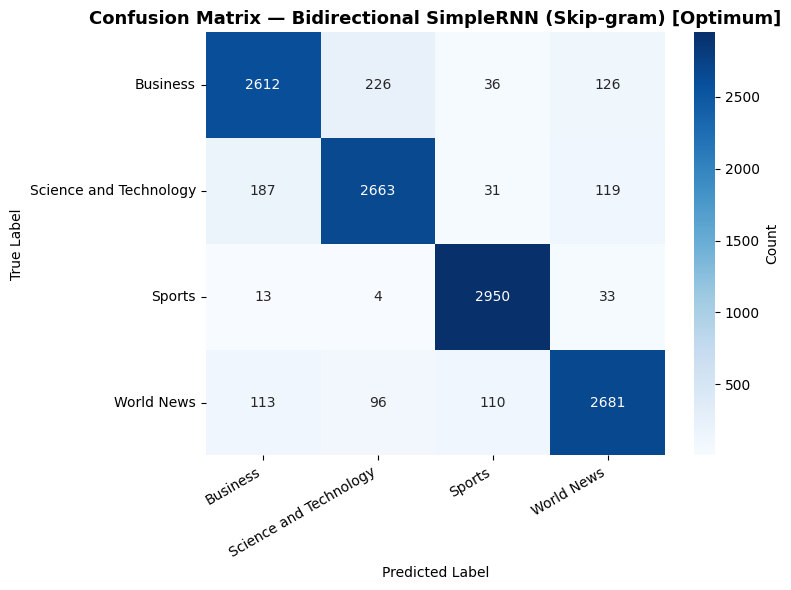


  ── Bidirectional GRU (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9339
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9346
      *** New best! ***
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9326
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9345
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9329
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9328
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9331
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9345
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9336
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9349
      

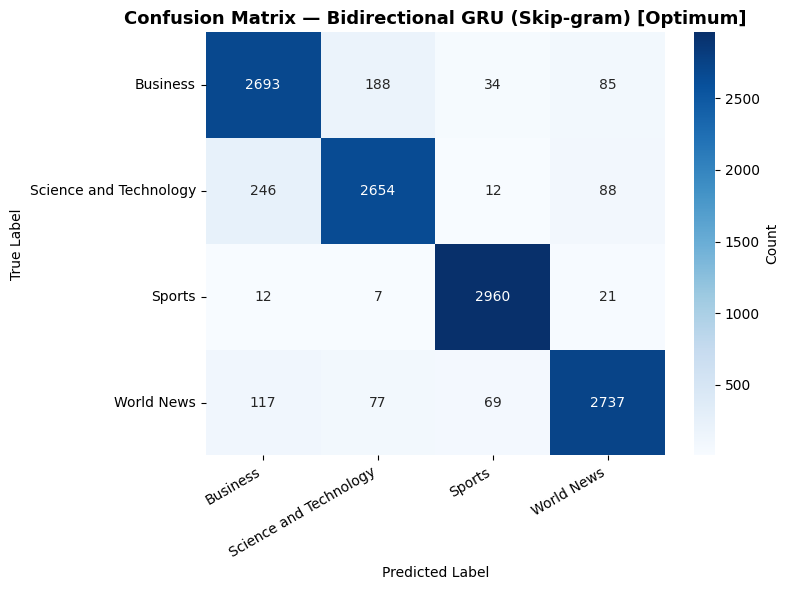


  ── Bidirectional LSTM (Skip-gram) ──
  Total configs: 16
    [1/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9329
      *** New best! ***
    [2/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.3}  Val=0.9324
    [3/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.2}  Val=0.9345
      *** New best! ***
    [4/16] {'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'dropout': 0.3}  Val=0.9334
    [5/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.2}  Val=0.9303
    [6/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 1, 'dropout': 0.3}  Val=0.9330
    [7/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.2}  Val=0.9333
    [8/16] {'hidden_dim': 64, 'lr': 0.0005, 'num_layers': 2, 'dropout': 0.3}  Val=0.9361
      *** New best! ***
    [9/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout': 0.2}  Val=0.9305
    [10/16] {'hidden_dim': 128, 'lr': 0.001, 'num_layers': 1, 'dropout'

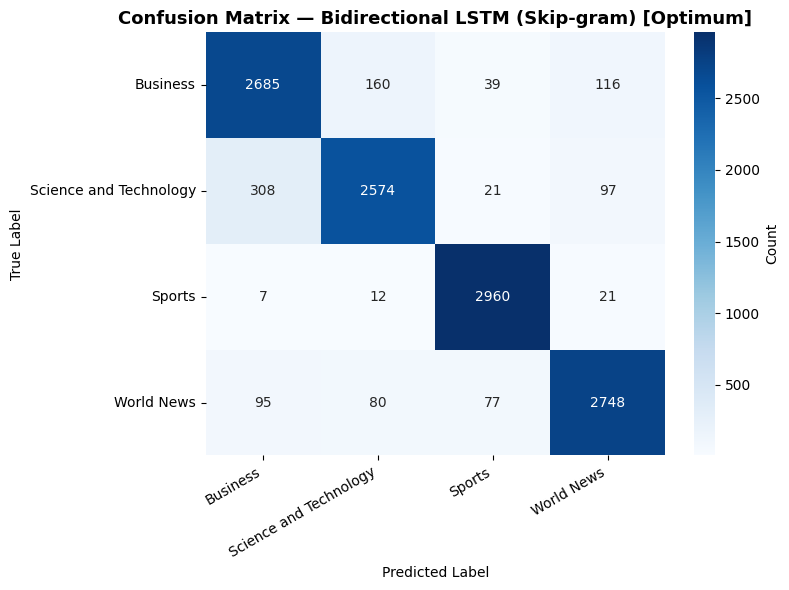

In [ ]:
# EXPERIMENTS 3–8 — RNN variants with Skip-gram
# (run for each of the 3 preprocessing variants)

rnn_experiments = [
    ('SimpleRNN (Skip-gram)',               'SimpleRNN', False),
    ('GRU (Skip-gram)',                     'GRU',       False),
    ('LSTM (Skip-gram)',                    'LSTM',      False),
    ('Bidirectional SimpleRNN (Skip-gram)', 'SimpleRNN', True),
    ('Bidirectional GRU (Skip-gram)',       'GRU',       True),
    ('Bidirectional LSTM (Skip-gram)',      'LSTM',      True),
]

for prep_name in PREPROCESSING_VARIANTS:
    print("\n" + "="*60)
    print(f"RNN Experiments — Preprocessing: [{prep_name}]")
    print("="*60)
    for exp_name, rnn_type, bidir in rnn_experiments:
        print(f"\n  ── {exp_name} ──")
        tune_rnn_for_variant(exp_name, rnn_type, prep_name, bidirectional=bidir)


FULL RESULTS — All Models × All Preprocessing Variants (sorted by F1 Macro within each variant)
Preprocessing                               Model Word Rep.           Type  Accuracy  F1 Macro
      Extreme                        DNN (TF-IDF)    TF-IDF Neural Network    0.9115    0.9112
      Extreme       Bidirectional GRU (Skip-gram) Skip-gram Neural Network    0.9108    0.9106
      Extreme                    LSTM (Skip-gram) Skip-gram Neural Network    0.9096    0.9092
      Extreme                     GRU (Skip-gram) Skip-gram Neural Network    0.9087    0.9084
      Extreme      Bidirectional LSTM (Skip-gram) Skip-gram Neural Network    0.9066    0.9060
      Extreme               SimpleRNN (Skip-gram) Skip-gram Neural Network    0.9017    0.9013
      Extreme Bidirectional SimpleRNN (Skip-gram) Skip-gram Neural Network    0.8933    0.8932
      Extreme              Random Forest (TF-IDF)    TF-IDF             ML    0.8708    0.8689
      Optimum       Bidirectional GRU (Skip-gram

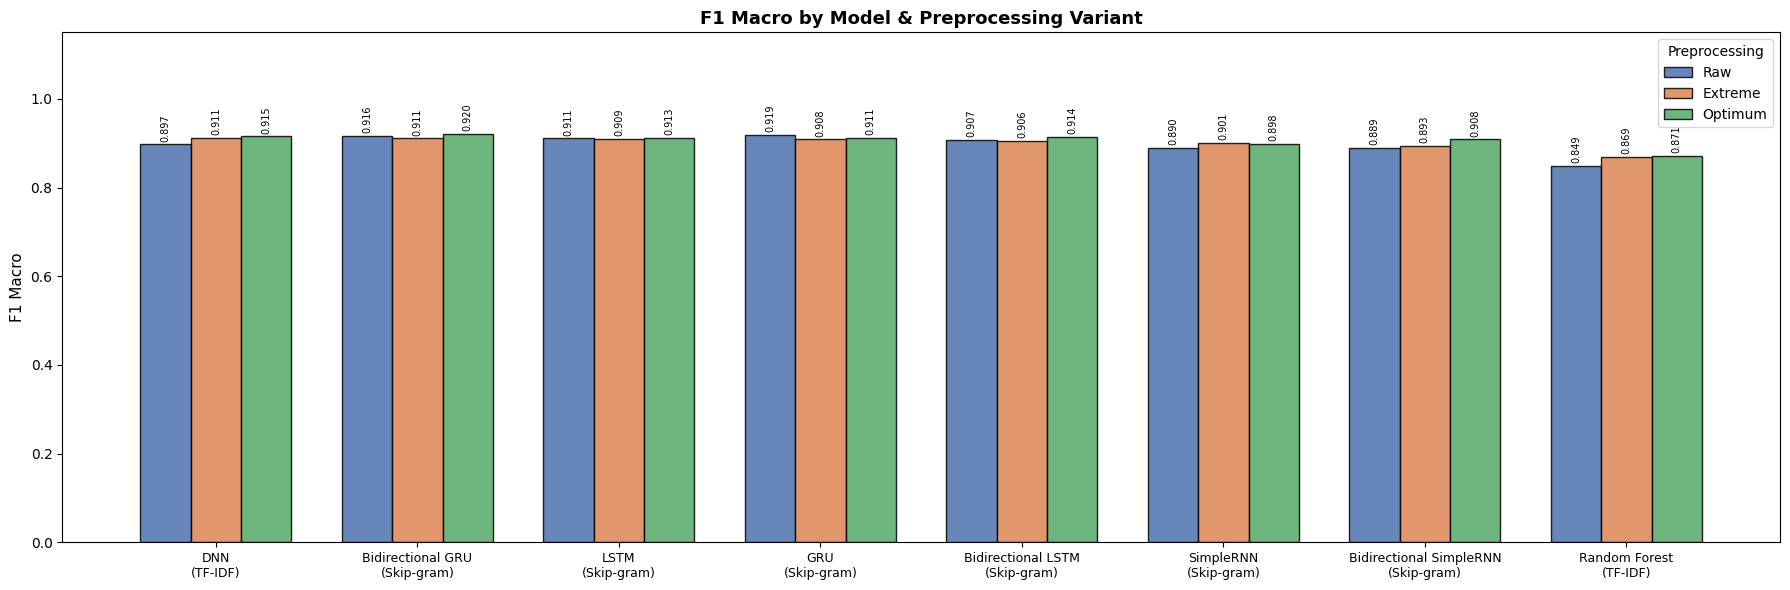


MEAN F1 MACRO BY PREPROCESSING VARIANT
  Raw         Mean F1=0.8973  Best F1=0.9194
  Extreme     Mean F1=0.9011  Best F1=0.9112
  Optimum     Mean F1=0.9064  Best F1=0.9202


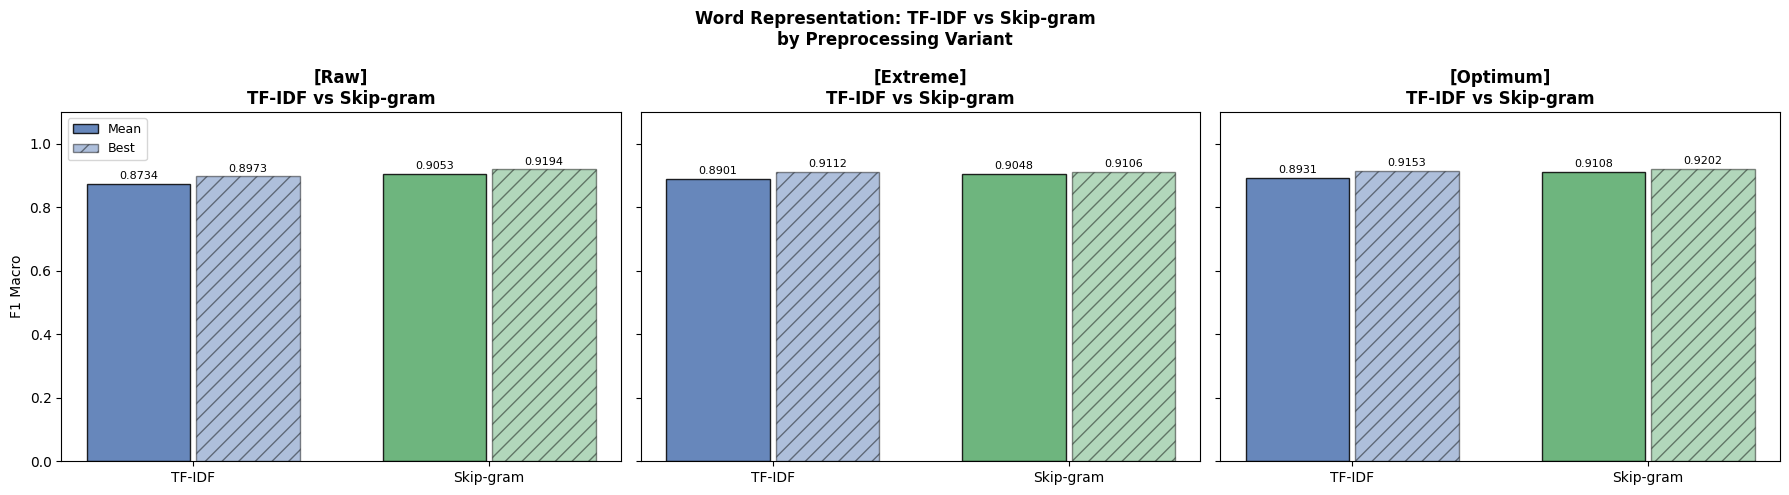

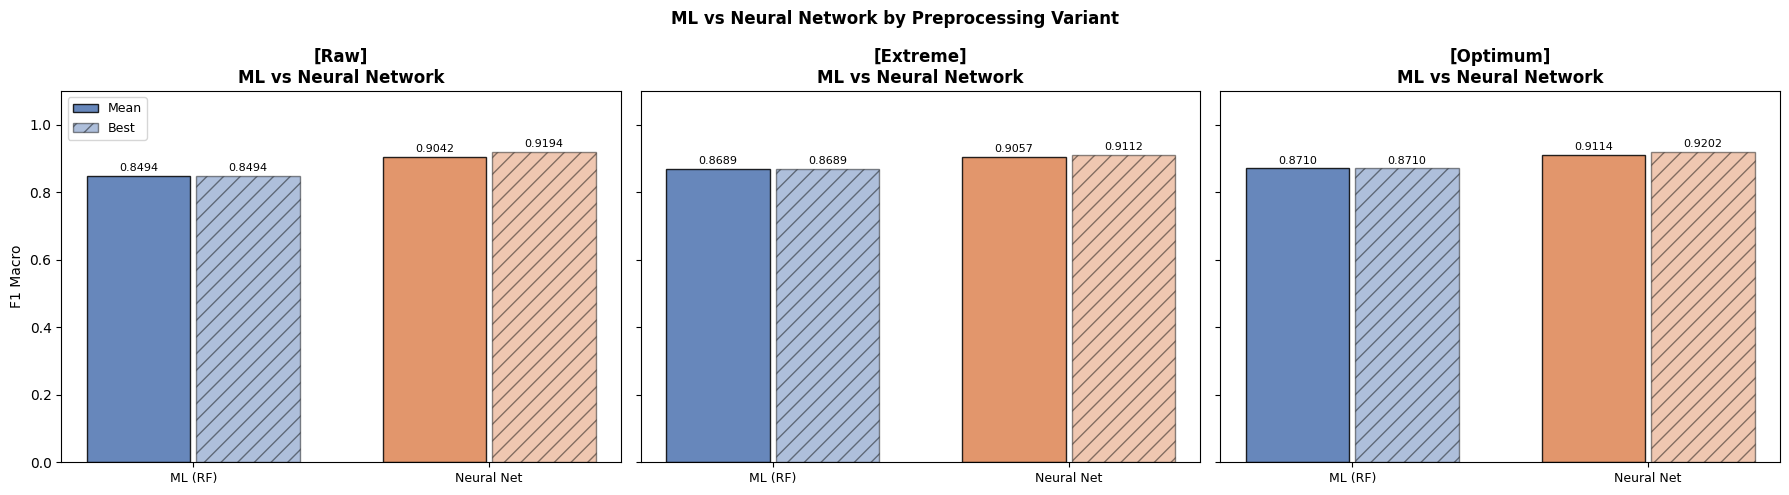


OVERALL CHAMPION (across all models × all preprocessing variants)
  Model:         Bidirectional GRU (Skip-gram)
  Preprocessing: Optimum
  Accuracy:      0.9203
  F1 Macro:      0.9202


In [ ]:
# FINAL COMPARISON — Results across all 3 preprocessing variants

import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import textwrap

# 1. Build combined summary DataFrame
rows = []
for prep_name, results_list in all_results.items():
    for r in results_list:
        rows.append({
            'Preprocessing': prep_name,
            'Model':         r['model'],
            'Word Rep.':     'Skip-gram' if 'Skip-gram' in r['model'] else 'TF-IDF',
            'Type':          'ML' if r['model'] == 'Random Forest (TF-IDF)' else 'Neural Network',
            'Accuracy':      round(r['accuracy'], 4),
            'F1 Macro':      round(r['f1_macro'], 4),
        })



summary_df = pd.DataFrame(rows).sort_values(
    ['Preprocessing', 'F1 Macro'], ascending=[True, False]
).reset_index(drop=True)

print("\n" + "="*85)
print("FULL RESULTS — All Models × All Preprocessing Variants (sorted by F1 Macro within each variant)")
print("="*85)
print(summary_df.to_string(index=False))
print("="*85)



# Best / worst per variant
print("\n" + "="*85)
print("BEST & WORST PER PREPROCESSING VARIANT")
print("="*85)
for prep_name in PREPROCESSING_VARIANTS:
    sub   = summary_df[summary_df['Preprocessing'] == prep_name]
    best  = sub.iloc[0]
    worst = sub.iloc[-1]
    print(f"\n[{prep_name}]")
    print(f"  🏆 BEST  : {best['Model']:<45}  Acc={best['Accuracy']:.4f}  F1={best['F1 Macro']:.4f}")
    print(f"  💀 WORST : {worst['Model']:<45}  Acc={worst['Accuracy']:.4f}  F1={worst['F1 Macro']:.4f}")



# 2. Grouped bar chart: F1 Macro by model × preprocessing variant
models          = summary_df['Model'].unique().tolist()
prep_names      = list(PREPROCESSING_VARIANTS.keys())
colours_prep    = {'Raw': '#4C72B0', 'Extreme': '#DD8452', 'Optimum': '#55A868'}

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
for i, prep_name in enumerate(prep_names):
    sub  = summary_df[summary_df['Preprocessing'] == prep_name].set_index('Model')
    vals = [sub.loc[m, 'F1 Macro'] if m in sub.index else 0 for m in models]
    bars = ax.bar(x + i * width, vals, width, label=prep_name,
                  color=colours_prep[prep_name], edgecolor='black', alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7, rotation=90)


ax.set_xticks(x + width)
ax.set_xticklabels(
    [m.replace(' (Skip-gram)', '\n(Skip-gram)').replace(' (TF-IDF)', '\n(TF-IDF)') for m in models],
    fontsize=9, ha='center'
)


ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('F1 Macro by Model & Preprocessing Variant', fontsize=13, fontweight='bold')
ax.legend(title='Preprocessing', fontsize=10)
plt.tight_layout()
plt.show()


# 3. Mean F1 per preprocessing variant
print("\n" + "="*60)
print("MEAN F1 MACRO BY PREPROCESSING VARIANT")
print("="*60)
for prep_name in prep_names:
    sub = summary_df[summary_df['Preprocessing'] == prep_name]
    print(f"  {prep_name:<10}  Mean F1={sub['F1 Macro'].mean():.4f}  Best F1={sub['F1 Macro'].max():.4f}")



# 4. Word-representation comparison (TF-IDF vs Skip-gram) per variant


fig, axes = plt.subplots(1, len(prep_names), figsize=(6 * len(prep_names), 5), sharey=True)
for ax, prep_name in zip(axes, prep_names):
    sub        = summary_df[summary_df['Preprocessing'] == prep_name]
    tfidf_m    = sub[sub['Word Rep.'] == 'TF-IDF']['F1 Macro']
    skipgram_m = sub[sub['Word Rep.'] == 'Skip-gram']['F1 Macro']
    x2    = np.arange(2)
    means = [tfidf_m.mean(), skipgram_m.mean()]
    maxes = [tfidf_m.max(),  skipgram_m.max()]
    bars  = ax.bar(x2,        means, 0.35, label='Mean', color=['#4C72B0','#55A868'], edgecolor='black', alpha=0.85)
    bars2 = ax.bar(x2 + 0.37, maxes, 0.35, label='Best', color=['#4C72B0','#55A868'], edgecolor='black', alpha=0.45, hatch='//')
    ax.set_xticks(x2 + 0.185)
    ax.set_xticklabels(['TF-IDF', 'Skip-gram'])
    ax.set_ylim(0, 1.1)
    ax.set_title(f'[{prep_name}]\nTF-IDF vs Skip-gram', fontweight='bold')
    ax.bar_label(bars,  fmt='%.4f', padding=2, fontsize=8)
    ax.bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('F1 Macro')
        ax.legend(fontsize=9)

plt.suptitle('Word Representation: TF-IDF vs Skip-gram\nby Preprocessing Variant',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# 5. ML vs NN per variant


fig, axes = plt.subplots(1, len(prep_names), figsize=(6 * len(prep_names), 5), sharey=True)
for ax, prep_name in zip(axes, prep_names):
    sub   = summary_df[summary_df['Preprocessing'] == prep_name]
    ml_m  = sub[sub['Type'] == 'ML']['F1 Macro']
    nn_m  = sub[sub['Type'] == 'Neural Network']['F1 Macro']
    x2    = np.arange(2)
    means = [ml_m.mean() if len(ml_m) else 0, nn_m.mean() if len(nn_m) else 0]
    maxes = [ml_m.max()  if len(ml_m) else 0, nn_m.max()  if len(nn_m) else 0]
    bars  = ax.bar(x2,        means, 0.35, label='Mean', color=['#4C72B0','#DD8452'], edgecolor='black', alpha=0.85)
    bars2 = ax.bar(x2 + 0.37, maxes, 0.35, label='Best', color=['#4C72B0','#DD8452'], edgecolor='black', alpha=0.45, hatch='//')
    ax.set_xticks(x2 + 0.185)
    ax.set_xticklabels(['ML (RF)', 'Neural Net'], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'[{prep_name}]\nML vs Neural Network', fontweight='bold')
    ax.bar_label(bars,  fmt='%.4f', padding=2, fontsize=8)
    ax.bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('F1 Macro')
        ax.legend(fontsize=9)

plt.suptitle('ML vs Neural Network by Preprocessing Variant', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Overall
champion = summary_df.sort_values('F1 Macro', ascending=False).iloc[0]
print("\n" + "="*75)
print("OVERALL CHAMPION (across all models × all preprocessing variants)")
print("="*75)
print(f"  Model:         {champion['Model']}")
print(f"  Preprocessing: {champion['Preprocessing']}")
print(f"  Accuracy:      {champion['Accuracy']:.4f}")
print(f"  F1 Macro:      {champion['F1 Macro']:.4f}")
print("="*75)